# From least squares to neural networks, PINNs, FNOs and PINOs

## A two-hour, executable introduction for materials-science students

This notebook develops one idea at a time:

> **Choose what mathematical object will be represented, calculate its prediction, measure disagreement, and adjust its parameters.**

The represented object changes:

| Method | What is represented? |
|---|---|
| Ordinary least squares (OLS) | A function with a supplied basis and a few fitted coefficients |
| Neural network (NN) | A flexible function with adjustable parameters |
| Physics-informed neural network (PINN) | Usually one trial solution field for one problem |
| Fourier neural operator (FNO) | A map from one field to another field across a family of problems |
| Physics-informed neural operator (PINO) | An operator trained using data and information from the governing equation |

The notebook repeatedly distinguishes a **network approximation**, a **named constitutive equation**, and a **physical mechanism**. They are not the same object.

### Google Colab instructions

1. Upload this notebook to Google Colab.
2. Select **Runtime → Run all**.
3. A GPU is optional. Every example also runs on a CPU.
4. Run cells in order because later sections reuse definitions introduced earlier.

All substantial code cells have a markdown cell before them explaining the aim and a markdown cell after them explaining how to read the result.

## Vocabulary used throughout

- **Input:** a number or collection of numbers supplied to a model.
- **Feature:** an input quantity used by a model. Grain size and position are examples.
- **Label or target:** a known output paired with an input.
- **Prediction:** the output calculated by the current model.
- **Parameter:** an adjustable number inside a model.
- **Residual:** prediction minus observation, or the amount by which a prediction violates an equation.
- **Loss:** one scalar number constructed from selected residuals.
- **Optimizer:** an algorithm that changes parameters to reduce a loss.
- **Epoch:** one complete training pass through the current training set.
- **Training set:** observations used to update model parameters.
- **Validation set:** separate observations used to select architecture, regularization and stopping time.
- **Test set:** observations kept untouched until the modelling procedure has been selected.

A test set is no longer independent if it repeatedly influences modelling decisions.

## 0. Set up a reproducible Colab environment

The next cell imports only packages already provided by Google Colab. It fixes random seeds, selects a GPU when one is available, and defines two small utility functions. Fixing a seed makes this teaching calculation repeatable; it does not remove uncertainty from a real experiment.

In [1]:
# Import the packages used throughout the notebook.
import copy
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Use one seed so repeated runs give the same teaching example.
SEED = 714
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Seed every GPU as well when CUDA is available.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Use a GPU when available; otherwise use the CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set a readable default figure size and font size.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.6),
    "font.size": 11,
})


# Convert a NumPy array to a PyTorch tensor on the selected device.
def to_tensor(array, requires_grad=False):
    return torch.tensor(
        array,
        dtype=torch.float32,
        device=device,
        requires_grad=requires_grad,
    )


# Calculate root-mean-square error in the original output units.
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


print("PyTorch version:", torch.__version__)
print("Device:", device)


PyTorch version: 2.11.0
Device: cpu


The printed device is only a computational choice. It does not change the mathematical models. The seed is used again when datasets and models are created so that the figures are reproducible.

## Part I — Ordinary Least Squares

## 1. Hall–Petch Relation as a Supplied Regression Model

For this example, we assume

$$
\sigma_y(d)=\sigma_0+kd^{-1/2}+\epsilon.
$$

Here, $d$ is the mean grain size, $\sigma_y$ is the yield strength, and $\epsilon$ represents measurement scatter and model discrepancy.

Defining the feature

$$
x=d^{-1/2}
$$

transforms the Hall–Petch relation into a model that is linear in the two unknown coefficients, $\sigma_0$ and $k$:

$$
\sigma_y=\sigma_0+kx.
$$

The next cell creates a synthetic dataset for teaching purposes. The numerical values are illustrative and are not intended to represent any particular alloy.

In [2]:
# Create a reproducible random-number generator
rng = np.random.default_rng(SEED)

# Generate 90 grain sizes between 1 and 100 µm.
# geomspace() is used because grain size spans two orders of magnitude.
# It gives approximately uniform coverage on a logarithmic scale, so the
# dataset contains sufficient points at both small and large grain sizes.
# This is more appropriate than linear spacing when studying the nonlinear
# dependence of yield strength on d through the feature d^(-1/2).
d_um = np.geomspace(1.0, 100.0, 90)

# Define the true Hall–Petch coefficients and measurement-noise level
sigma0_true = 155.0   # Friction stress, MPa
k_true = 345.0        # Hall–Petch coefficient, MPa·µm^(1/2)
noise_sd = 12.0       # Standard deviation of measurement noise, MPa

# Transform grain size into the linear regression feature x = d^(-1/2)
x_hp = d_um**(-0.5)   # Units: µm^(-1/2)

# Calculate the noise-free yield strength
sigma_clean = sigma0_true + k_true * x_hp

# Add normally distributed measurement noise
sigma_measured = sigma_clean + rng.normal(
    loc=0.0,
    scale=noise_sd,
    size=d_um.size
)

# Randomly shuffle the observation indices
indices = rng.permutation(d_um.size)

# Split the dataset into training, validation, and test sets
train_idx = indices[:54]      # 60% of the data
val_idx = indices[54:72]      # 20% of the data
test_idx = indices[72:]       # 20% of the data

# Display the sizes of the three data subsets
print(
    "Training/validation/test sizes:",
    len(train_idx),
    len(val_idx),
    len(test_idx)
)

# Display the coefficients used to generate the synthetic dataset
print("True coefficients:", sigma0_true, k_true)

Training/validation/test sizes: 54 18 18
True coefficients: 155.0 345.0


The clean curve is known only because this is a synthetic example. In an experiment, the clean curve and true coefficients are unknown. The split is performed before fitting so that later evaluation is not performed on the same observations used to estimate the coefficients.

## 2. Solve the OLS Problem

For each training observation, the design matrix contains the supplied basis functions $1$ and $d^{-1/2}$:

$$
X =
\begin{bmatrix}
1 & d_1^{-1/2} \\
\vdots & \vdots \\
1 & d_N^{-1/2}
\end{bmatrix}.
$$

Ordinary least squares chooses the two coefficients that minimize the sum of squared residuals over the training data:

$$
\min_{\sigma_0,k}
\sum_{i=1}^{N}
\left[
\sigma_{y,i}
-
\left(
\sigma_0 + k\,d_i^{-1/2}
\right)
\right]^2.
$$

In matrix form, this is

$$
\min_{\boldsymbol{\beta}}
\left\|
X\boldsymbol{\beta} - \mathbf{y}
\right\|_2^2,
$$

where

$$
\boldsymbol{\beta}
=
\begin{bmatrix}
\sigma_0 \\
k
\end{bmatrix}.
$$

We solve this problem using `numpy.linalg.lstsq`. This approach is numerically safer than explicitly evaluating

$$
\left(X^\mathsf{T}X\right)^{-1}X^\mathsf{T}\mathbf{y},
$$

because forming $X^\mathsf{T}X$ can worsen numerical conditioning, while explicitly computing a matrix inverse is unnecessary.

In [3]:
# Construct the design matrix for all 90 observations.
# Column 1 corresponds to the intercept term sigma_0.
# Column 2 corresponds to the Hall–Petch feature x = d^(-1/2).
X_all = np.column_stack([
    np.ones_like(x_hp),
    x_hp
])

# Use the previously generated indices to create the data split explicitly.
X_train = X_all[train_idx]
y_train = sigma_measured[train_idx]

X_val = X_all[val_idx]
y_val = sigma_measured[val_idx]

X_test = X_all[test_idx]
y_test = sigma_measured[test_idx]

# Fit the OLS model using only the training subset.
# The validation and test subsets are not used to determine the coefficients.
beta_ols, *_ = np.linalg.lstsq(
    X_train,
    y_train,
    rcond=None
)

# Extract the fitted Hall–Petch coefficients.
sigma0_ols, k_ols = beta_ols

# Generate predictions separately for each subset.
sigma_pred_train = X_train @ beta_ols
sigma_pred_val = X_val @ beta_ols
sigma_pred_test = X_test @ beta_ols

# Calculate the RMSE for the training, validation, and test subsets.
print(
    f"{'train':10s} RMSE = "
    f"{rmse(y_train, sigma_pred_train):6.2f} MPa"
)

print(
    f"{'validation':10s} RMSE = "
    f"{rmse(y_val, sigma_pred_val):6.2f} MPa"
)

print(
    f"{'test':10s} RMSE = "
    f"{rmse(y_test, sigma_pred_test):6.2f} MPa"
)

# Display the Hall–Petch coefficients recovered from the training data.
print(f"Recovered sigma0 = {sigma0_ols:.2f} MPa")
print(f"Recovered k      = {k_ols:.2f} MPa·µm^(1/2)")

train      RMSE =  11.48 MPa
validation RMSE =  12.16 MPa
test       RMSE =   9.84 MPa
Recovered sigma0 = 150.97 MPa
Recovered k      = 352.56 MPa·µm^(1/2)


The recovered coefficients will not equal the synthetic values exactly because the training observations contain noise. OLS has estimated the coefficients of the Hall–Petch form supplied before fitting. It has not discovered that form or proved a particular strengthening mechanism.

## 3. Inspect predictions and residuals

The next cell plots the fit in the transformed coordinate and plots residuals against grain size. A residual pattern can reveal missing structure even when one summary metric appears satisfactory.

In [4]:
# Predict yield strength for all grain-size values.
# This array is used for plotting the complete fitted Hall–Petch line.
sigma_pred_ols = X_all @ beta_ols

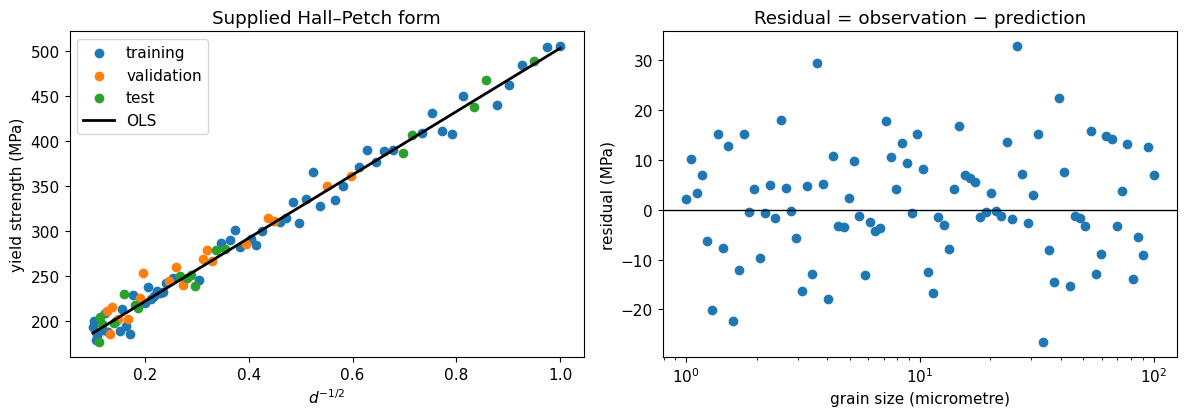

In [5]:
# Plot the OLS fit and check whether the residuals show a clear pattern.
order = np.argsort(x_hp)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].scatter(x_hp[train_idx], sigma_measured[train_idx], label="training")
ax[0].scatter(x_hp[val_idx], sigma_measured[val_idx], label="validation")
ax[0].scatter(x_hp[test_idx], sigma_measured[test_idx], label="test")
ax[0].plot(x_hp[order], sigma_pred_ols[order], "k", lw=2, label="OLS")
ax[0].set(xlabel=r"$d^{-1/2}$", ylabel="yield strength (MPa)",
          title="Supplied Hall–Petch form")
ax[0].legend()

residuals = sigma_measured - sigma_pred_ols
ax[1].axhline(0, color="k", lw=1)
ax[1].scatter(d_um, residuals)
ax[1].set_xscale("log")
ax[1].set(xlabel="grain size (micrometre)", ylabel="residual (MPa)",
          title="Residual = observation − prediction")
plt.tight_layout()
plt.show()

Random scatter around zero is compatible with the chosen model and noise description. A systematic curve, changing spread, or isolated group would be a reason to revisit the model, measurement process, or omitted state variables.

## 4. Recover Hall–Petch parameters using gradient-based optimization

If the scientific goal is to recover $\sigma_0$ and $k$, the safest model contains exactly those two trainable quantities:

$$
\widehat{\sigma}_y=\sigma_0+k\,d^{-1/2}.
$$

Using PyTorch to optimize this expression does not make it a neural network. It remains the prescribed Hall–Petch model.

In [6]:
# Define the supplied Hall–Petch equation as a PyTorch model.
# Only sigma0 and k are adjusted during optimization.
class HallPetchModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Starting guesses for the two fitted coefficients.
        self.sigma0 = nn.Parameter(torch.tensor(100.0))
        self.k = nn.Parameter(torch.tensor(250.0))

    def forward(self, grain_size):
        # Calculate sigma_y = sigma0 + k / sqrt(d).
        return self.sigma0 + self.k / torch.sqrt(grain_size)


# Create the model and move it to the selected CPU or GPU.
hp_model = HallPetchModel().to(device)

# LBFGS works well for this small problem with only two unknowns.
opt_hp = torch.optim.LBFGS(
    hp_model.parameters(),
    lr=0.8,
    max_iter=250,
    line_search_fn="strong_wolfe",
)

# Convert only the training data to PyTorch tensors.
d_train_t = to_tensor(d_um[train_idx, None])
y_train_t = to_tensor(sigma_measured[train_idx, None])


# LBFGS calls this function several times while choosing each update.
def hp_closure():
    opt_hp.zero_grad()

    # Mean squared error between measured and predicted strengths.
    prediction = hp_model(d_train_t)
    loss_hp = torch.mean((prediction - y_train_t) ** 2)

    # Calculate gradients of the loss with respect to sigma0 and k.
    loss_hp.backward()
    return loss_hp


# Adjust sigma0 and k to reduce the training loss.
opt_hp.step(hp_closure)

# Print the fitted coefficients.
print(
    "Gradient-trained sigma0:",
    float(hp_model.sigma0.detach().cpu()),
)
print(
    "Gradient-trained k:     ",
    float(hp_model.k.detach().cpu()),
)


Gradient-trained sigma0: 150.96937561035156
Gradient-trained k:      352.55792236328125


The gradient-trained values should agree closely with OLS. The difference is the optimization algorithm, not the represented equation. To recover a named constitutive form, that form must be imposed or identified using a separate symbolic/model-selection procedure.

# Part II — Neural networks as flexible functions

## 5. One neuron and one forward calculation

A **weight** multiplies an input, a **bias** is added, and an **activation function** applies a fixed nonlinear transformation. For one input $x$,

$$
z=wx+b,\qquad h=\tanh(z).
$$

The next cell calculates every number explicitly. No learning occurs during a forward calculation.

In [7]:
# Work through one neuron by hand before training a network.
x_demo = 0.8
w_demo = 1.7
b_demo = -0.2
z_demo = w_demo*x_demo + b_demo
h_demo = np.tanh(z_demo)

print("input x              =", x_demo)
print("weight times input   =", w_demo*x_demo)
print("add bias: z          =", z_demo)
print("apply tanh: output h =", h_demo)

input x              = 0.8
weight times input   = 1.36
add bias: z          = 1.1600000000000001
apply tanh: output h = 0.8210398813328772


Training is a separate process that changes the weight and bias. A forward calculation only evaluates the current function.

## 6. A synthetic turnover dataset

To discuss reported inverse Hall–Petch-type behaviour without presenting one universal inverse equation, we create a clearly labelled synthetic curve. It contains Hall–Petch-like strengthening over part of the range and a smooth nanoscale softening term.

This curve is a teaching device. It is not proposed as a universal constitutive law or mechanism.

In [8]:
# Create a synthetic strength curve that first rises and then falls.
d_nm = np.geomspace(5.0, 200.0, 90)
def turnover_truth(d):
    hp_part = 140.0 + 850.0/np.sqrt(d)
    softening = 320.0/(1.0 + np.exp((d-18.0)/3.0))
    return hp_part - softening

strength_true = turnover_truth(d_nm)
strength_obs = strength_true + rng.normal(0.0, 10.0, d_nm.size)
perm = rng.permutation(d_nm.size)
nn_train, nn_val, nn_test = perm[:30], perm[30:50], perm[50:]

logd = np.log10(d_nm)
x_mean, x_std = logd[nn_train].mean(), logd[nn_train].std()
y_mean, y_std = strength_obs[nn_train].mean(), strength_obs[nn_train].std()
x_scaled = (logd-x_mean)/x_std
y_scaled = (strength_obs-y_mean)/y_std
print("NN split:", len(nn_train), len(nn_val), len(nn_test))

NN split: 30 20 40


In [33]:
# Create grain sizes from 4 to 200 nm.
# geomspace() gives good coverage across both the fine- and coarse-grain ranges.
d_nm = np.geomspace(4.0, 200.0, 120)

def turnover_truth(d):
    # Hall–Petch strengthening:
    # strength increases as grain size decreases.
    hp_part = 150.0 + 900.0 / np.sqrt(d)

    # Fine-grain softening:
    # this term becomes important below about 20 nm.
    # It produces a clear inverse Hall–Petch branch.
    softening = 500.0 / (1.0 + np.exp((d - 22.0) / 5.0))

    # The competition between strengthening and softening
    # produces a maximum at an intermediate grain size.
    return hp_part - softening

# Generate the noise-free strength curve.
strength_true = turnover_truth(d_nm)

# Add random measurement scatter.
strength_obs = strength_true + rng.normal(
    loc=0.0,
    scale=10.0,
    size=d_nm.size
)

# Randomly divide the data into training, validation, and test subsets.
perm = rng.permutation(d_nm.size)

nn_train = perm[:72]       # 60%
nn_val = perm[72:96]       # 20%
nn_test = perm[96:]        # 20%

# Use log10(d) because grain size spans nearly two orders of magnitude.
logd = np.log10(d_nm)

# Calculate scaling parameters using only the training data.
x_mean = logd[nn_train].mean()
x_std = logd[nn_train].std()

y_mean = strength_obs[nn_train].mean()
y_std = strength_obs[nn_train].std()

# Scale the input and output values for neural-network training.
x_scaled = (logd - x_mean) / x_std
y_scaled = (strength_obs - y_mean) / y_std

print(
    "NN split:",
    len(nn_train),
    len(nn_val),
    len(nn_test)
)

NN split: 72 24 24


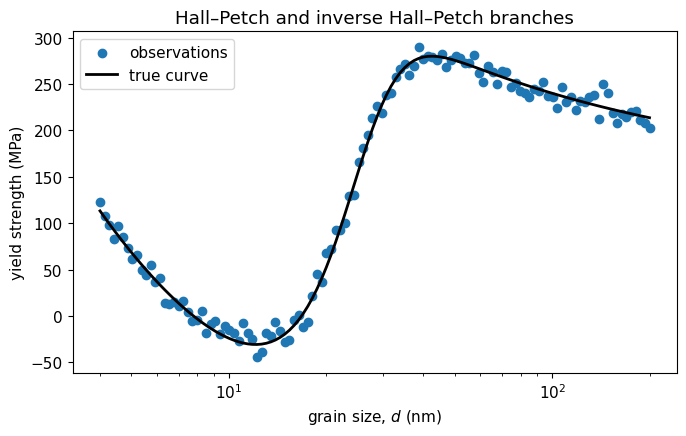

In [34]:
# Sort the grain sizes so that the true curve is drawn smoothly.
order = np.argsort(d_nm)

plt.figure(figsize=(7, 4.5))

# Plot the noisy observations.
plt.scatter(
    d_nm,
    strength_obs,
    label="observations"
)

# Plot the underlying turnover curve.
plt.plot(
    d_nm[order],
    strength_true[order],
    color="black",
    linewidth=2,
    label="true curve"
)

plt.xscale("log")
plt.xlabel(r"grain size, $d$ (nm)")
plt.ylabel("yield strength (MPa)")
plt.title("Hall–Petch and inverse Hall–Petch branches")
plt.legend()
plt.tight_layout()
plt.show()

The training set is deliberately small and noisy so that underfitting and overfitting can be seen. Inputs and outputs are scaled using training-set statistics only. Using validation or test statistics would leak information.

## 7. Define a small multilayer perceptron and a training procedure

A multilayer perceptron (MLP) composes linear transformations and activation functions. The training function below records training and validation losses, supports early stopping, and can restore the parameter values with the lowest validation loss.

In [35]:
# Define a small fully connected neural network.
class MLP(nn.Module):

    def __init__(self, widths, activation=nn.Tanh):
        super().__init__()

        # Start with one input feature: scaled log10(grain size).
        input_size = 1

        # Store the layers in a Python list before combining them.
        layers = []

        # Add the hidden layers.
        for width in widths:
            layers.append(nn.Linear(input_size, width))
            layers.append(activation())

            # The output size of this layer becomes the input size
            # of the next layer.
            input_size = width

        # Add the final output layer.
        # The network predicts one value: scaled yield strength.
        layers.append(nn.Linear(input_size, 1))

        # Combine all layers into one sequential model.
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Pass the input through the complete network.
        return self.net(x)


# Train a neural network using training and validation data.
def fit_supervised(
    model,
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=1500,
    learning_rate=1e-3,
    patience=150,
    restore_best=True
):
    # Move the model to the selected device.
    # This may be the CPU, GPU, or Apple MPS device.
    model = model.to(device)

    # Adam adjusts the network weights during training.
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    # Store the training and validation losses after each epoch.
    history = {
        "train": [],
        "val": []
    }

    # Keep track of the best validation result.
    best_val_loss = np.inf
    best_state = None
    best_epoch = None

    # Count how many consecutive epochs show no validation improvement.
    epochs_without_improvement = 0

    for epoch in range(epochs):

        # -------------------------
        # Training step
        # -------------------------
        model.train()

        # Remove gradients left from the previous epoch.
        optimizer.zero_grad()

        # Predict the training values.
        y_train_pred = model(x_train)

        # Mean squared error between prediction and observation.
        train_loss = torch.mean(
            (y_train_pred - y_train) ** 2
        )

        # Calculate gradients of the loss.
        train_loss.backward()

        # Update the network weights.
        optimizer.step()

        # -------------------------
        # Validation step
        # -------------------------
        model.eval()

        # No gradients are needed during validation.
        with torch.no_grad():
            y_val_pred = model(x_val)

            val_loss = torch.mean(
                (y_val_pred - y_val) ** 2
            )

        # Convert the losses to ordinary Python numbers.
        train_loss_value = train_loss.item()
        val_loss_value = val_loss.item()

        # Save the loss history.
        history["train"].append(train_loss_value)
        history["val"].append(val_loss_value)

        # Check whether the validation loss has improved.
        if val_loss_value < best_val_loss:
            best_val_loss = val_loss_value
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Stop if the validation loss has not improved
        # for the specified number of epochs.
        if restore_best and epochs_without_improvement >= patience:
            break

    # Restore the weights from the epoch with the lowest validation loss.
    if restore_best and best_state is not None:
        model.load_state_dict(best_state)

    # Store useful information about the best model.
    best = {
        "val_loss": best_val_loss,
        "epoch": best_epoch,
        "state_dict": best_state
    }

    return model, history, best

The optimizer sees only training labels. Validation loss is calculated without a parameter update. Early stopping chooses an epoch using validation data; it must not use the test set.

## 8. Train an underfitting, balanced and overfitting model

The models use the same training observations but different capacities and stopping rules:

- the underfitting model is only a straight line;
- the balanced model is a modest two-layer network selected by validation loss;
- the overfitting model is much larger and is allowed to continue fitting the small noisy training set.

In [38]:
# Convert the training inputs and outputs to PyTorch tensors.
# [:, None] changes each one-dimensional array into a column vector.
x_train_tensor = to_tensor(x_scaled[nn_train, None])
y_train_tensor = to_tensor(y_scaled[nn_train, None])

# Convert the validation inputs and outputs to PyTorch tensors.
x_val_tensor = to_tensor(x_scaled[nn_val, None])
y_val_tensor = to_tensor(y_scaled[nn_val, None])



# Model 1: too simple


# Reset the random seed so that weight initialization is reproducible.
torch.manual_seed(SEED)

# MLP([]) has no hidden layer.
# It is only a linear relation between the input and output.
# It cannot reproduce the curved strength–grain-size relation.
under_model, under_history, under_best = fit_supervised(
    model=MLP([]),
    x_train=x_train_tensor,
    y_train=y_train_tensor,
    x_val=x_val_tensor,
    y_val=y_val_tensor,
    epochs=900,
    learning_rate=3e-3,
    patience=150,
    restore_best=True
)


# ------------------------------------------------------------
# Model 2: suitable capacity
# ------------------------------------------------------------

# Reset the seed so that comparisons between models are reproducible.
torch.manual_seed(SEED)

# This network has two hidden layers with 16 neurons in each layer.
# It has enough flexibility to learn the two branches without being excessive.
right_model, right_history, right_best = fit_supervised(
    model=MLP([16, 16]),
    x_train=x_train_tensor,
    y_train=y_train_tensor,
    x_val=x_val_tensor,
    y_val=y_val_tensor,
    epochs=2200,
    learning_rate=2e-3,
    patience=220,
    restore_best=True
)


# ------------------------------------------------------------
# Model 3: unnecessarily large
# ------------------------------------------------------------

# Reset the seed again for reproducibility.
torch.manual_seed(SEED)

# This network has three hidden layers with 128 neurons in each layer.
# It has far more parameters than needed for this small dataset.
#
# restore_best=False means that the final model is retained,
# even if its validation loss became worse during later epochs.
# This is done deliberately to demonstrate overfitting.
over_model, over_history, over_best = fit_supervised(
    model=MLP(
        widths=[128, 128, 128],
        activation=nn.ReLU
    ),
    x_train=x_train_tensor,
    y_train=y_train_tensor,
    x_val=x_val_tensor,
    y_val=y_val_tensor,
    epochs=2600,
    learning_rate=2e-3,
    patience=2600,
    restore_best=False
)


# Report the epoch at which each model had its lowest validation loss.
# Epoch numbering starts from zero in Python, so add 1 for display.
print(
    "Balanced model selected epoch:",
    right_best["epoch"] + 1
)

print(
    "Large model lowest validation-loss epoch:",
    over_best["epoch"] + 1
)

print(
    "The final large-model epoch was retained deliberately "
    "to show overfitting."
)

Balanced model selected epoch: 355
Large model lowest validation-loss epoch: 2182
The final large-model epoch was retained deliberately to show overfitting.


The large model is intentionally not restored to its best validation epoch. That is a teaching choice made to expose what can happen when training continues after validation performance stops improving.

## 9. Compare the three fitted functions and their losses

The next cell evaluates all three models on a dense grain-size grid and reports errors separately for training, validation and test observations.

underfit  RMSE train/validation/test =  74.88 /  59.65 /  81.23
balanced  RMSE train/validation/test =  11.59 /  10.09 /  13.40
overfit   RMSE train/validation/test =   5.94 /  10.86 /  10.39


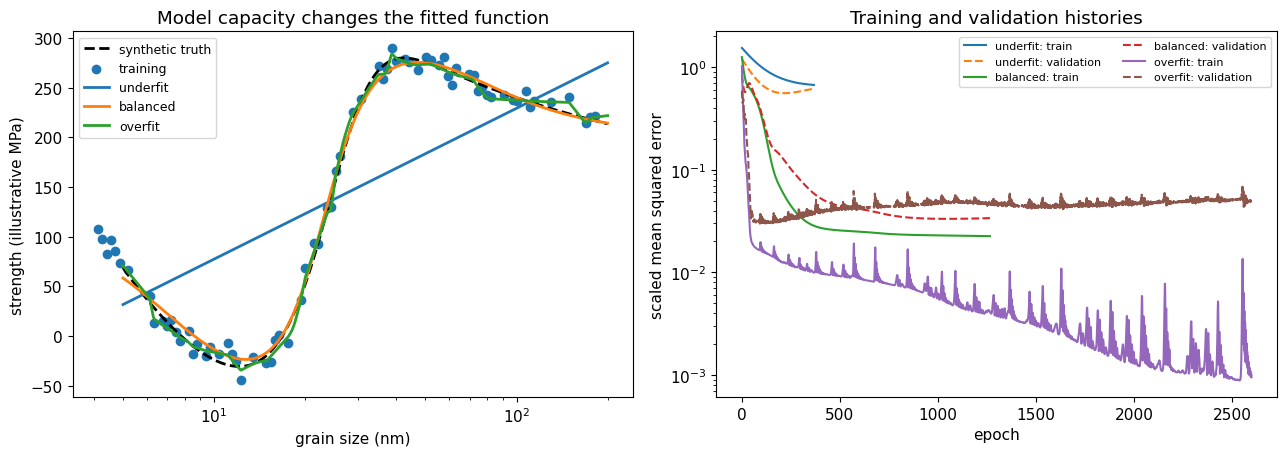

In [39]:
# Convert network outputs back to physical units and compare the models.
def predict_strength(model, d_values):
    z = (np.log10(d_values)-x_mean)/x_std
    with torch.no_grad():
        yp = model(to_tensor(z[:, None])).cpu().numpy().ravel()
    return yp*y_std + y_mean

d_dense = np.geomspace(5.0, 200.0, 400)
models = {"underfit": under_model, "balanced": right_model,
          "overfit": over_model}
for name, model in models.items():
    pred_all = predict_strength(model, d_nm)
    values = [rmse(strength_obs[idx], pred_all[idx])
              for idx in (nn_train, nn_val, nn_test)]
    print(f"{name:9s} RMSE train/validation/test = "
          f"{values[0]:6.2f} / {values[1]:6.2f} / {values[2]:6.2f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.7))
ax[0].plot(d_dense, turnover_truth(d_dense), "k--", lw=2,
           label="synthetic truth")
ax[0].scatter(d_nm[nn_train], strength_obs[nn_train], label="training")
for name, model in models.items():
    ax[0].plot(d_dense, predict_strength(model, d_dense), lw=2, label=name)
ax[0].set_xscale("log")
ax[0].set(xlabel="grain size (nm)", ylabel="strength (illustrative MPa)",
          title="Model capacity changes the fitted function")
ax[0].legend(fontsize=9)

for name, hist in [("underfit", under_hist), ("balanced", right_hist),
                   ("overfit", over_hist)]:
    ax[1].plot(hist["train"], label=f"{name}: train")
    ax[1].plot(hist["val"], "--", label=f"{name}: validation")
ax[1].set_yscale("log")
ax[1].set(xlabel="epoch", ylabel="scaled mean squared error",
          title="Training and validation histories")
ax[1].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

Underfitting normally gives large training and validation errors. Overfitting gives a very small training error but poorer validation or test performance. The balanced model is selected using validation data and is evaluated only afterwards on the untouched test observations. A small train–validation gap alone is not sufficient: both errors may be large.

##  Bias and Variance

Suppose the measured output at an input $x$ is

$$
y = f(x) + \epsilon,
$$

where

- $f(x)$ is the true relation between the input and output,
- $\epsilon$ is random measurement noise,
- $\mathbb{E}[\epsilon]=0$,
- $\operatorname{Var}(\epsilon)=\sigma_\epsilon^2$.

A model fitted to a training dataset gives the prediction

$$
\widehat{f}(x).
$$

The hat indicates that $\widehat{f}(x)$ is estimated from data. If we used a different training dataset, we would generally obtain a different fitted model and therefore a different value of $\widehat{f}(x)$.

We want to understand the expected squared prediction error at a fixed input $x$:

$$
\mathbb{E}
\left[
\left(
y-\widehat{f}(x)
\right)^2
\right].
$$

Substituting $y=f(x)+\epsilon$ gives

$$
\mathbb{E}
\left[
\left(
f(x)+\epsilon-\widehat{f}(x)
\right)^2
\right].
$$

Rearranging the terms,

$$
\mathbb{E}
\left[
\left(
f(x)-\widehat{f}(x)+\epsilon
\right)^2
\right].
$$

Expanding the square gives

$$
\mathbb{E}
\left[
\left(
f(x)-\widehat{f}(x)
\right)^2
\right]
+
2\mathbb{E}
\left[
\epsilon
\left(
f(x)-\widehat{f}(x)
\right)
\right]
+
\mathbb{E}[\epsilon^2].
$$

The noise is assumed to have zero mean and to be independent of the fitted model. Therefore, the middle term is zero:

$$
\mathbb{E}
\left[
\epsilon
\left(
f(x)-\widehat{f}(x)
\right)
\right]
=0.
$$

Also,

$$
\mathbb{E}[\epsilon^2]
=
\sigma_\epsilon^2.
$$

Hence,

$$
\mathbb{E}
\left[
\left(
y-\widehat{f}(x)
\right)^2
\right]
=
\mathbb{E}
\left[
\left(
f(x)-\widehat{f}(x)
\right)^2
\right]
+
\sigma_\epsilon^2.
$$

We now separate the model error into bias and variance.

Let the average prediction over many possible training datasets be

$$
\mathbb{E}\left[\widehat{f}(x)\right].
$$

Add and subtract this average prediction:

$$
f(x)-\widehat{f}(x)
=
f(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
+
\mathbb{E}\left[\widehat{f}(x)\right]
-
\widehat{f}(x).
$$

Therefore,

$$
\mathbb{E}
\left[
\left(
f(x)-\widehat{f}(x)
\right)^2
\right]
=
\mathbb{E}
\left[
\left(
f(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
+
\mathbb{E}\left[\widehat{f}(x)\right]
-
\widehat{f}(x)
\right)^2
\right].
$$

After expanding, the cross term is zero because

$$
\mathbb{E}
\left[
\widehat{f}(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
\right]
=0.
$$

We obtain

$$
\mathbb{E}
\left[
\left(
f(x)-\widehat{f}(x)
\right)^2
\right]
=
\left(
f(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
\right)^2
+
\mathbb{E}
\left[
\left(
\widehat{f}(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
\right)^2
\right].
$$

The first term is the squared bias:

$$
\operatorname{Bias}\left[\widehat{f}(x)\right]^2
=
\left(
\mathbb{E}\left[\widehat{f}(x)\right]
-
f(x)
\right)^2.
$$

The second term is the variance:

$$
\operatorname{Variance}\left[\widehat{f}(x)\right]
=
\mathbb{E}
\left[
\left(
\widehat{f}(x)
-
\mathbb{E}\left[\widehat{f}(x)\right]
\right)^2
\right].
$$

Combining the results gives the bias–variance decomposition:

$$
\boxed{
\mathbb{E}
\left[
\left(
y-\widehat{f}(x)
\right)^2
\right]
=
\operatorname{Bias}\left[\widehat{f}(x)\right]^2
+
\operatorname{Variance}\left[\widehat{f}(x)\right]
+
\sigma_\epsilon^2
}
$$

### Meaning of the three terms

**Bias** measures how far the average prediction is from the true value $f(x)$.

A model with high bias is systematically wrong. This usually happens when the model is too simple to represent the true relation.

**Variance** measures how much the prediction changes when a different training dataset is used.

A model with high variance is very sensitive to the particular observations used for training. This usually happens when the model is too flexible for the available amount of data.

The term $\sigma_\epsilon^2$ is the noise variance. It represents random variation in the measurements and cannot be removed by improving the model.

Thus, the expected prediction error contains three contributions:

$$
\text{prediction error}
=
\text{squared bias}
+
\text{variance}
+
\text{irreducible noise}.
$$

A very simple model usually has high bias and low variance. A very flexible model usually has low training error but may have high variance. The aim is to find a model that gives a reasonable balance between the two.

Bias and variance describe behavior across many possible training datasets. They cannot be determined completely from one fitted model. In the next experiment, we generate many noisy datasets and fit polynomial models of different degrees to make these effects visible.



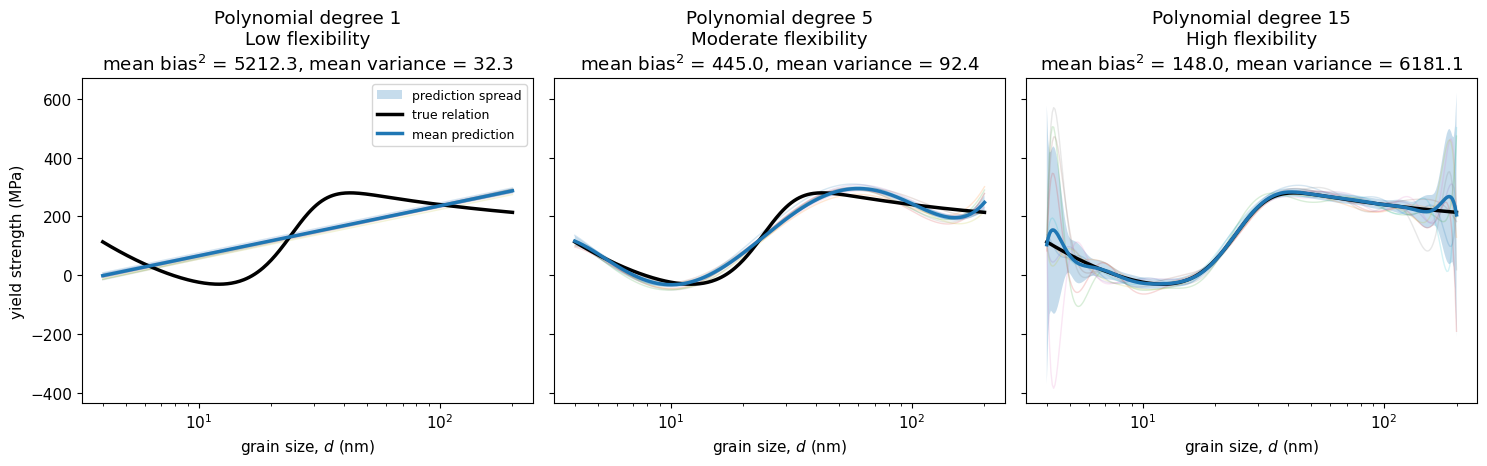

In [48]:
# Import the numerically stable polynomial fitting class.
from numpy.polynomial import Polynomial


# Define a synthetic grain-size–strength relation.
# At larger grain sizes, the Hall–Petch term increases strength
# as grain size decreases.
#
# At very small grain sizes, the softening term reduces strength.
# The result is a curve with a maximum at an intermediate grain size.
def hall_petch_with_small_grain_softening(d):
    hall_petch_part = 150.0 + 900.0 / np.sqrt(d)

    small_grain_softening = (
        500.0
        / (1.0 + np.exp((d - 22.0) / 5.0))
    )

    return hall_petch_part - small_grain_softening


# Create a common grain-size grid for plotting all predictions.
d_grid = np.geomspace(4.0, 200.0, 300)

# Use log10(grain size) as the polynomial input.
# This gives a more even representation of the grain-size range.
z_grid = np.log10(d_grid)

# Evaluate the true strength relation on the plotting grid.
strength_true_grid = (
    hall_petch_with_small_grain_softening(d_grid)
)


# Compare polynomial models with different levels of flexibility.
#
# Degree 1 is too simple.
# Degree 4 has moderate flexibility.
# Degree 10 is highly flexible.
degrees = [1, 5, 15]

titles = [
    "Low flexibility",
    "Moderate flexibility",
    "High flexibility"
]


# Number of independent noisy datasets.
n_repeats = 100

# Number of observations in each dataset.
n_samples = 20

# Standard deviation of the added measurement noise.
noise_sd = 18.0


# Create one subplot for each polynomial degree.
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.8),
    sharex=True,
    sharey=True
)


for ax, degree, title in zip(axes, degrees, titles):

    # Store one predicted curve for each repeated dataset.
    predictions = []

    for repeat in range(n_repeats):

        # Use a different but reproducible random-number generator
        # for each repeated dataset.
        rng_repeat = np.random.default_rng(
            1000 + repeat
        )

        # Start with logarithmically spaced grain sizes.
        d_sample = np.geomspace(
            4.0,
            200.0,
            n_samples
        )

        # Slightly change the grain-size locations in each dataset.
        # This represents experiments performed at somewhat different
        # grain sizes.
        d_sample = (
            d_sample
            * rng_repeat.uniform(
                0.92,
                1.08,
                size=n_samples
            )
        )

        # Keep all grain sizes inside the chosen physical range.
        d_sample = np.clip(
            d_sample,
            4.0,
            200.0
        )

        # Sort the values only for convenience.
        d_sample = np.sort(d_sample)

        # Generate the noise-free strength values.
        strength_sample_true = (
            hall_petch_with_small_grain_softening(
                d_sample
            )
        )

        # Add random measurement noise.
        strength_sample = (
            strength_sample_true
            + rng_repeat.normal(
                loc=0.0,
                scale=noise_sd,
                size=n_samples
            )
        )

        # Transform grain size to log10(d).
        z_sample = np.log10(d_sample)

        # Fit a polynomial of the selected degree.
        #
        # Polynomial.fit() rescales the input internally,
        # so it is more stable than np.polyfit() for higher degrees.
        polynomial_model = Polynomial.fit(
            z_sample,
            strength_sample,
            deg=degree
        )

        # Predict strength on the common plotting grid.
        strength_prediction = (
            polynomial_model(z_grid)
        )

        predictions.append(
            strength_prediction
        )


    # Convert the list to an array.
    #
    # Shape:
    # rows    = repeated datasets
    # columns = grain-size grid points
    predictions = np.asarray(predictions)


    # Calculate the average prediction at each grain size.
    mean_prediction = predictions.mean(
        axis=0
    )

    # Calculate the spread of predictions at each grain size.
    prediction_std = predictions.std(
        axis=0
    )


    # Bias is the difference between the mean prediction
    # and the true relation.
    bias = (
        mean_prediction
        - strength_true_grid
    )

    # Calculate the squared bias at each grain size.
    squared_bias = bias**2

    # Variance measures how strongly predictions change
    # from one repeated dataset to another.
    variance = predictions.var(
        axis=0
    )


    # Average the squared bias over the full grain-size range.
    mean_squared_bias = squared_bias.mean()

    # Average the variance over the full grain-size range.
    mean_variance = variance.mean()


    # Plot a small number of individual fitted curves.
    # These curves show how much the fitted model changes
    # when the training dataset changes.
    for curve in predictions[:10]:
        ax.plot(
            d_grid,
            curve,
            linewidth=1,
            alpha=0.18
        )


    # Show one standard deviation above and below
    # the mean prediction.
    ax.fill_between(
        d_grid,
        mean_prediction - prediction_std,
        mean_prediction + prediction_std,
        alpha=0.25,
        label="prediction spread"
    )


    # Plot the true grain-size–strength relation.
    ax.plot(
        d_grid,
        strength_true_grid,
        color="black",
        linewidth=2.5,
        label="true relation"
    )


    # Plot the mean prediction across all repeated datasets.
    ax.plot(
        d_grid,
        mean_prediction,
        linewidth=2.5,
        label="mean prediction"
    )


    # Use a logarithmic grain-size axis.
    ax.set_xscale("log")

    ax.set_xlabel(
        r"grain size, $d$ (nm)"
    )

    ax.set_title(
        f"Polynomial degree {degree}\n"
        f"{title}\n"
        f"mean bias$^2$ = {mean_squared_bias:.1f}, "
        f"mean variance = {mean_variance:.1f}"
    )


# Add the common vertical-axis label.
axes[0].set_ylabel(
    "yield strength (MPa)"
)

# Show the legend only once.
axes[0].legend(
    fontsize=9
)

plt.tight_layout()
plt.show()

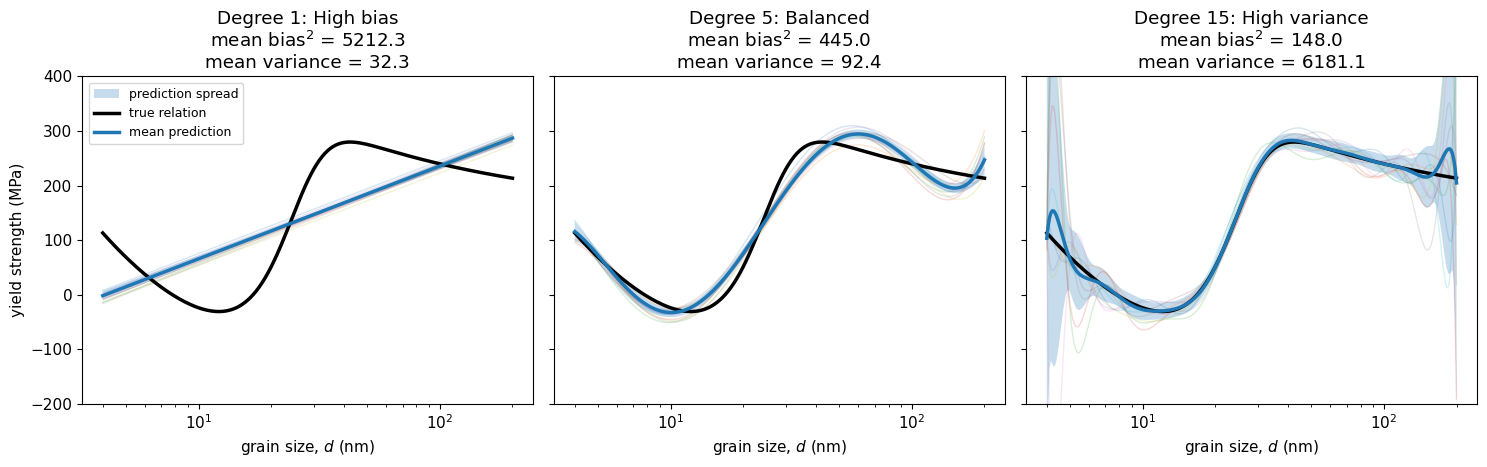

In [54]:
from numpy.polynomial import Polynomial

# Define the synthetic grain-size–strength relation.
def hall_petch_with_small_grain_softening(d):
    hall_petch_part = 150.0 + 900.0 / np.sqrt(d)

    small_grain_softening = (
        500.0
        / (1.0 + np.exp((d - 22.0) / 5.0))
    )

    return hall_petch_part - small_grain_softening


# Common grid used to display every fitted model.
d_grid = np.geomspace(4.0, 200.0, 300)
z_grid = np.log10(d_grid)

strength_true_grid = (
    hall_petch_with_small_grain_softening(d_grid)
)


# Settings for the repeated-data experiment.
degrees = [1, 5, 15]

titles = [
    "High bias",
    "Balanced",
    "High variance"
]

n_repeats = 100
n_samples = 20
noise_sd = 18.0


# Generate the repeated noisy datasets only once.
# Every polynomial degree will therefore use exactly the same datasets.
datasets = []

for repeat in range(n_repeats):

    rng_repeat = np.random.default_rng(1000 + repeat)

    # Generate grain sizes distributed across the full range.
    d_sample = np.geomspace(
        4.0,
        200.0,
        n_samples
    )

    # Slightly vary the measurement positions.
    d_sample = (
        d_sample
        * rng_repeat.uniform(
            0.92,
            1.08,
            size=n_samples
        )
    )

    d_sample = np.clip(
        d_sample,
        4.0,
        200.0
    )

    d_sample = np.sort(d_sample)

    # Generate noisy yield-strength measurements.
    strength_sample = (
        hall_petch_with_small_grain_softening(d_sample)
        + rng_repeat.normal(
            loc=0.0,
            scale=noise_sd,
            size=n_samples
        )
    )

    datasets.append(
        (d_sample, strength_sample)
    )


# Create the three comparison plots.
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.8),
    sharex=True,
    sharey=True
)


for ax, degree, title in zip(
    axes,
    degrees,
    titles
):

    predictions = []

    # Fit the selected polynomial degree to every dataset.
    for d_sample, strength_sample in datasets:

        z_sample = np.log10(d_sample)

        # Polynomial.fit() rescales the input internally.
        polynomial_model = Polynomial.fit(
            z_sample,
            strength_sample,
            deg=degree
        )

        strength_prediction = (
            polynomial_model(z_grid)
        )

        predictions.append(
            strength_prediction
        )

    predictions = np.asarray(predictions)

    # Average prediction across repeated datasets.
    mean_prediction = predictions.mean(axis=0)

    # Spread of predictions across repeated datasets.
    prediction_std = predictions.std(axis=0)

    # Bias squared at each grain size.
    squared_bias = (
        mean_prediction
        - strength_true_grid
    ) ** 2

    # Variance at each grain size.
    variance = predictions.var(axis=0)

    mean_squared_bias = squared_bias.mean()
    mean_variance = variance.mean()

    # Plot a few individual fitted curves.
    for curve in predictions[:10]:
        ax.plot(
            d_grid,
            curve,
            linewidth=1,
            alpha=0.18
        )

    # Show the prediction spread.
    ax.fill_between(
        d_grid,
        mean_prediction - prediction_std,
        mean_prediction + prediction_std,
        alpha=0.25,
        label="prediction spread"
    )

    # Plot the true relation.
    ax.plot(
        d_grid,
        strength_true_grid,
        color="black",
        linewidth=2.5,
        label="true relation"
    )

    # Plot the average prediction.
    ax.plot(
        d_grid,
        mean_prediction,
        linewidth=2.5,
        label="mean prediction"
    )

    ax.set_xscale("log")
    ax.set_xlabel(r"grain size, $d$ (nm)")

    ax.set_title(
        f"Degree {degree}: {title}\n"
        f"mean bias$^2$ = {mean_squared_bias:.1f}\n"
        f"mean variance = {mean_variance:.1f}"
    )


# Use the same vertical range in every panel.
# This prevents automatic scaling from exaggerating or hiding differences.
for ax in axes:
    ax.set_ylim(-200.0, 400.0)

axes[0].set_ylabel("yield strength (MPa)")
axes[0].legend(fontsize=9)

plt.tight_layout()
plt.show()

The low-degree models are stable but systematically wrong. The very high-degree models can change greatly when the sampled observations change. Modern neural networks can show more complicated behaviour than this classical picture, but repeated-dataset sensitivity remains the correct meaning of variance.

## 11. What the neural network has—and has not—recovered

The balanced network represents a fitted function $f_\theta(d)$. It may approximate Hall–Petch-like or turnover data, but it has not become

$$
\sigma_y=\sigma_0+k\,d^{-1/2}.
$$

To recover $\sigma_0$ and $k$, fit the prescribed Hall–Petch model as done earlier. To ask whether a compact equation can be discovered from data, use a separate symbolic/model-identification procedure and validate the selected expression independently.

Interpolation within the measured range is also different from extrapolation. A model trained only in a conventional grain-size regime cannot be expected to invent nanoscale softening outside its training domain.

# Part III — A forward PINN without measured interior solution data

## Problem and terminology

Consider

$$
-u''(x)=\pi^2\sin(\pi x),\quad 0\le x\le1,\qquad u(0)=u(1)=0.
$$

A **collocation point** is a coordinate where the equation is checked although no solution label is supplied. **Automatic differentiation** applies the chain rule to the implemented network to calculate derivatives. A forward PINN can work without measured interior values of $u$, but not without information: the equation, domain and boundary conditions provide the information.

The exact solution $u=\sin(\pi x)$ is withheld from the training loss and used only as a final reference.

## Define the trial solution and residual

The network represents $u_\theta(x)$, not the Poisson equation. The residual is

$$
r_\theta(x)=-u_\theta''(x)-\pi^2\sin(\pi x).
$$

The next cell defines the network and uses automatic differentiation twice. The returned residual remains connected to the network parameters, so it can be minimized.

In [58]:
# Define a neural trial solution for the one-dimensional Poisson problem.
class PoissonPINN(nn.Module):
    def __init__(self, width=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width), nn.Tanh(),
            nn.Linear(width, width), nn.Tanh(),
            nn.Linear(width, 1))
    def forward(self, x):
        return self.net(x)

def poisson_residual(model, x):
    xg = x.clone().detach().requires_grad_(True)
    u = model(xg)
    ux = torch.autograd.grad(
        u, xg, torch.ones_like(u), create_graph=True)[0]
    uxx = torch.autograd.grad(
        ux, xg, torch.ones_like(ux), create_graph=True)[0]
    r = -uxx - torch.pi**2*torch.sin(torch.pi*xg)
    return r, u

Automatic differentiation differentiates the finite network expression to floating-point precision. It does not know the exact solution. A residual value of zero means that the current trial function satisfies the differential equation at that sampled coordinate.

## 14. Train using equation and boundary losses

Training coordinates update the parameters. Separate validation coordinates monitor the residual between those samples. One set of parameters controls the prediction over the whole domain, so each update is global in its effect, although the loss is evaluated at finitely many points.

In [59]:
# Set the PyTorch random seed so that the network starts from the same
# initial weights each time the cell is run.
torch.manual_seed(SEED)

# Create the PINN model and move it to the selected device.
pinn = PoissonPINN().to(device)


# Create 64 collocation points inside the domain 0 < x < 1.
# These points are used to evaluate the differential-equation residual.
x_f = to_tensor(
    np.random.default_rng(SEED).uniform(
        0.0,
        1.0,
        size=(64, 1)
    )
)


# Create a denser set of interior points for monitoring the residual
# during training.
# Note that these points are not used to update the network weights.
# We use these to check how well the differential equation
# is satisfied away from the training collocation points.
x_val = to_tensor(
    np.linspace(
        0.005,
        0.995,
        127
    )[:, None]
)


# Define the two boundary locations x = 0 and x = 1.
x_boundary = to_tensor([
    [0.0],
    [1.0]
])


# Define the required boundary values.
# Here the boundary conditions are u(0) = 0 and u(1) = 0.
u_boundary = to_tensor([
    [0.0],
    [0.0]
])


# Use the Adam optimizer to update the neural-network parameters.
optimizer = torch.optim.Adam(
    pinn.parameters(),
    lr=2e-3
)


# Store the loss history.
#
# "eq" records the differential-equation residual loss.
# "bc" records the boundary-condition loss.
# "val" records the total monitoring loss on the validation points.
history = {
    "eq": [],
    "bc": [],
    "val": []
}


# Store selected solution curves during training.
# These snapshots help show how the PINN solution develops with epoch.
snapshots = {}


# Store the lowest validation loss and the corresponding model weights.
best_val_loss = np.inf
best_state = None


# Train the PINN.
for epoch in range(1800):

    # Put the model in training mode.
    pinn.train()

    # Remove gradients left from the previous epoch.
    optimizer.zero_grad()


    # Evaluate the Poisson-equation residual at the collocation points.
    #
    # The function returns both the residual and the predicted solution.
    # Only the residual is needed here.
    residual_f, _ = poisson_residual(
        pinn,
        x_f
    )


    # Equation loss:
    # penalize deviations from the governing differential equation.
    equation_loss = torch.mean(
        residual_f**2
    )


    # Boundary-condition loss:
    # penalize differences between the predicted and prescribed
    # boundary values.
    boundary_loss = torch.mean(
        (
            pinn(x_boundary)
            - u_boundary
        )**2
    )


    # Combine the equation and boundary losses.
    #
    # The factor 50 gives additional weight to the boundary conditions
    # so that they are enforced strongly during training.
    total_loss = (
        equation_loss
        + 50.0 * boundary_loss
    )


    # Calculate gradients of the total loss.
    total_loss.backward()

    # Update the neural-network weights.
    optimizer.step()


    # Put the model in evaluation mode before monitoring its performance.
    pinn.eval()


    # Evaluate the differential-equation residual on the validation points.
    residual_val, _ = poisson_residual(
        pinn,
        x_val
    )


    # Calculate the monitoring loss.
    #
    # It contains the residual loss on the validation points
    # and the boundary-condition loss.
    validation_loss = (
        torch.mean(residual_val**2)
        + 50.0
        * torch.mean(
            (
                pinn(x_boundary)
                - u_boundary
            )**2
        )
    )


    # Store the three loss values as ordinary Python numbers.
    history["eq"].append(
        equation_loss.item()
    )

    history["bc"].append(
        boundary_loss.item()
    )

    history["val"].append(
        validation_loss.item()
    )


    # Save the model whenever the validation loss improves.
    if validation_loss.item() < best_val_loss:
        best_val_loss = validation_loss.item()
        best_state = copy.deepcopy(
            pinn.state_dict()
        )


    # Save the predicted solution at selected epochs.
    if epoch in [0, 25, 100, 400, 1799]:

        # Create a dense grid for plotting the solution.
        x_plot = to_tensor(
            np.linspace(
                0.0,
                1.0,
                300
            )[:, None]
        )

        # Gradients are not needed when storing the solution curve.
        with torch.no_grad():
            snapshots[epoch] = (
                pinn(x_plot)
                .cpu()
                .numpy()
                .ravel()
            )


# Restore the model weights that gave the lowest validation loss.
if best_state is not None:
    pinn.load_state_dict(best_state)

No exact interior value entered the loss. Boundary values are known conditions, not measured interior labels. The validation residual selected the retained parameters. A small sampled residual is evidence, not proof, that the equation is satisfied everywhere.

## Compare training snapshots with the reference solution kept out of training

The next cell displays how the global trial function changes during optimization. It also evaluates the retained model on a dense test grid and plots its residual there.

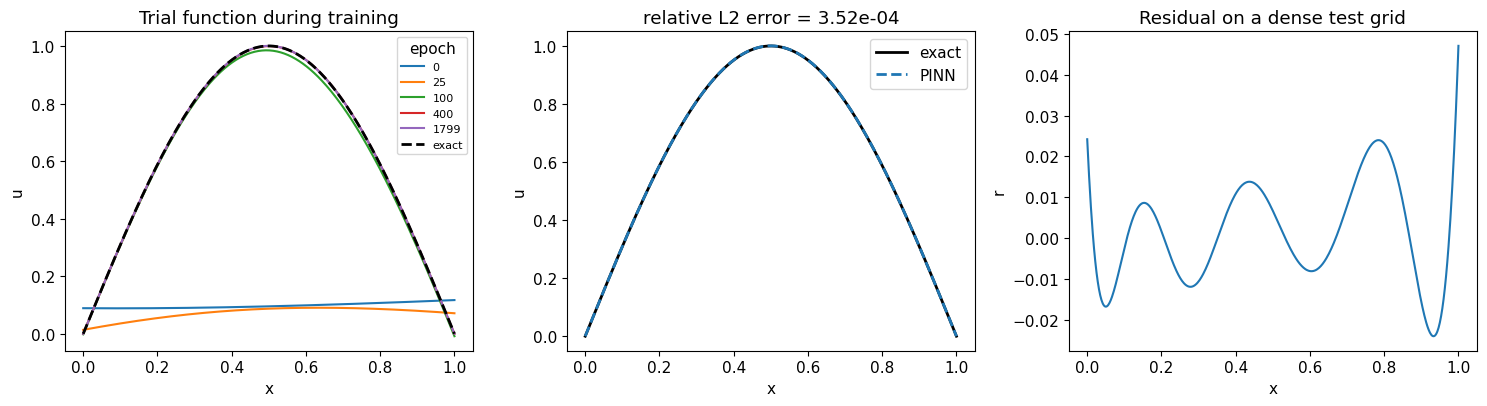

In [60]:
# Compare saved training stages with the exact solution kept out of training.
x_test_p = np.linspace(0, 1, 600)
u_exact_p = np.sin(np.pi*x_test_p)
with torch.no_grad():
    u_pred_p = pinn(to_tensor(x_test_p[:, None])).cpu().numpy().ravel()
r_test_p, _ = poisson_residual(pinn, to_tensor(x_test_p[:, None]))
r_test_p = r_test_p.detach().cpu().numpy().ravel()

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for epoch, values in snapshots.items():
    ax[0].plot(np.linspace(0, 1, 300), values, label=str(epoch))
ax[0].plot(x_test_p, u_exact_p, "k--", lw=2, label="exact")
ax[0].set(title="Trial function during training", xlabel="x", ylabel="u")
ax[0].legend(title="epoch", fontsize=8)
ax[1].plot(x_test_p, u_exact_p, "k", lw=2, label="exact")
ax[1].plot(x_test_p, u_pred_p, "--", lw=2, label="PINN")
ax[1].set(title=f"relative L2 error = {np.linalg.norm(u_pred_p-u_exact_p)/np.linalg.norm(u_exact_p):.2e}",
          xlabel="x", ylabel="u")
ax[1].legend()
ax[2].plot(x_test_p, r_test_p)
ax[2].set(title="Residual on a dense test grid", xlabel="x", ylabel="r")
plt.tight_layout(); plt.show()

The exact analytical solution is more accurate for this stated problem because it has no approximation error. A PINN has finite representation, sampling and optimization errors. A high-resolution conventional solver is also normally faster and more accurate for one known forward problem. PINNs are valuable when equations must be coupled with sparse observations, unknown parameters or repeated differentiable inverse calculations.

## 16. Loss histories and possible PINN failures

The following plot separates equation, boundary and validation losses. A PINN may fail because its network is too small, optimization stalls, loss terms are badly balanced, or collocation points are too sparse.

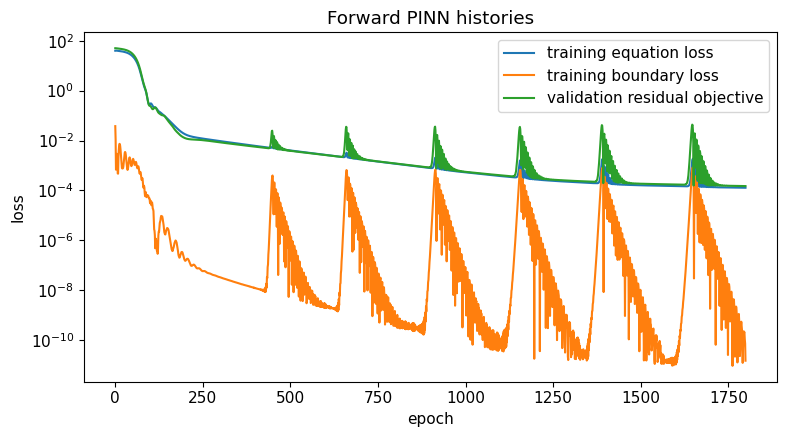

In [62]:
# Plot the PINN loss histories to check how training progressed.
plt.figure(figsize=(8, 4.5))
plt.semilogy(ph["eq"], label="training equation loss")
plt.semilogy(ph["bc"], label="training boundary loss")
plt.semilogy(ph["val"], label="validation residual objective")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Forward PINN histories")
plt.legend(); plt.tight_layout(); plt.show()

Low training residual but high validation residual indicates training-point overfitting. High values for both indicate underfitting or optimization failure. A low PDE residual can still select the wrong solution if boundary or initial conditions are missing, because the equation alone may admit multiple solutions.

# Part IV — Binary diffusion as an inverse PINN

## Forward and inverse directions

$$
\frac{\partial c}{\partial t}
=\frac{\partial}{\partial x}
\left[\widetilde D(c)\frac{\partial c}{\partial x}\right].
$$

The forward problem uses known $\widetilde D(c)$ to calculate $c(x,t)$. The inverse problem uses a measured profile to estimate $\widetilde D(c)$. This teaching example assumes one-dimensional, isothermal, single-phase diffusion; $\widetilde D$ depends only on composition; and Boltzmann similarity is valid.

The next cell defines a synthetic constitutive truth. It is used to generate data and is hidden again until final testing.

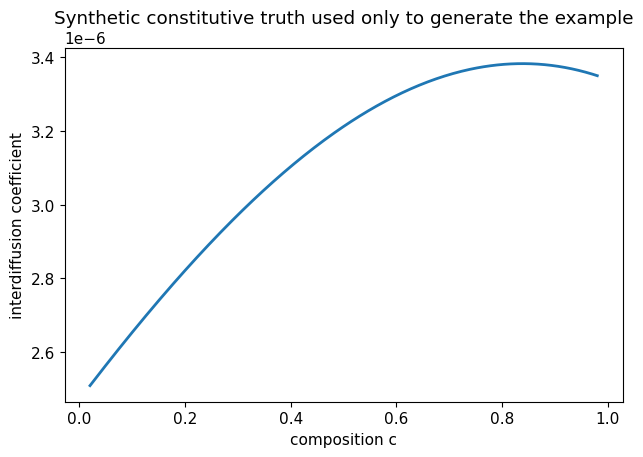

In [69]:
# Define the synthetic composition-dependent diffusivity used in this example.
R, T_const = 8.314, 1200.0
D0_true, Omega_true = 5.0e-5, -1800.0
a_true = np.array([30000.0, -4000.0, 1000.0])

def Q_np(c, a):
    return a[0] + a[1]*c + a[2]*c**2
def Dkin_np(c, a):
    return D0_true*np.exp(-Q_np(c, a)/(R*T_const))
def phi_np(c):
    return 1.0-(2.0*Omega_true/(R*T_const))*c*(1.0-c)
def Dtilde_np(c, a):
    return Dkin_np(c, a)*phi_np(c)

cq = np.linspace(0.02, 0.98, 300)
plt.plot(cq, Dtilde_np(cq, a_true), lw=2)
plt.xlabel("composition c"); plt.ylabel("interdiffusion coefficient")
plt.title("Synthetic constitutive truth used only to generate the example")
plt.show()

The assumed chosen form of the constitutive equation is already strong information: an Arrhenius kinetic factor, quadratic activation energy, fixed prefactor, fixed thermodynamic interaction and fixed temperature. The inverse calculation will recover only three coefficients within this family, not an arbitrary function.

## 18. Generate a synthetic diffusion-couple profile

The next cell solves the conservative diffusion equation using a simple finite-volume update. The far ends use zero-flux numerical boundaries and remain close to terminal compositions $c_L=0.8$ and $c_R=0.2$.

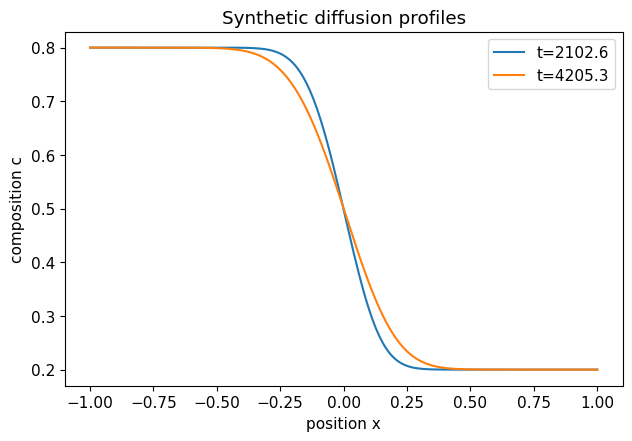

In [70]:
# Generate a synthetic diffusion-couple profile by solving the forward problem.
L, Nx = 2.0, 301
x_diff = np.linspace(-L/2, L/2, Nx)
dx = x_diff[1]-x_diff[0]
cL, cR = 0.80, 0.20
c_now = np.where(x_diff < 0, cL, cR).astype(float)
dt = 0.08*dx**2/np.max(Dtilde_np(np.linspace(0,1,300), a_true))
profiles = {}
for step in range(1, 4001):
    Dv = Dtilde_np(c_now, a_true)
    cp, dp = np.pad(c_now, 1, mode="edge"), np.pad(Dv, 1, mode="edge")
    grad_half = (cp[1:]-cp[:-1])/dx
    flux_half = -0.5*(dp[1:]+dp[:-1])*grad_half
    c_now += dt*(-(flux_half[1:]-flux_half[:-1])/dx)
    c_now = np.clip(c_now, 1e-7, 1-1e-7)
    if step in [2000, 4000]:
        profiles[step*dt] = c_now.copy()

for tv, cv in profiles.items():
    plt.plot(x_diff, cv, label=f"t={tv:.1f}")
plt.xlabel("position x"); plt.ylabel("composition c")
plt.title("Synthetic diffusion profiles"); plt.legend(); plt.show()

This numerical profile plays the role of an experimental measurement. In a real experiment, position and time units must be consistent because $\widetilde D$ has units of length squared per time.

## 19. Matano plane and Boltzmann coordinate

Mass balance locates the Matano plane $x_M$. With

$$
\lambda=(x-x_M)/\sqrt t,\qquad c(x,t)=c(\lambda),
$$

the PDE becomes

$$
-\frac{\lambda}{2}\frac{dc}{d\lambda}
=\frac{d}{d\lambda}\left[\widetilde D(c)\frac{dc}{d\lambda}\right].
$$

The next cell constructs scaled inputs and separate training and validation profile points.

In [68]:
# Find the Matano plane and form the Boltzmann coordinate.
t_latest = max(profiles)
c_latest = profiles[t_latest]
si = np.argsort(c_latest)
cs, xs = c_latest[si], x_diff[si]
x_M = np.sum(0.5*(xs[:-1]+xs[1:])*np.diff(cs))/np.sum(np.diff(cs))
lam = (x_diff-x_M)/np.sqrt(t_latest)
lam_scale = np.max(np.abs(lam))
lam_hat = lam/lam_scale
profile_train = np.arange(Nx) % 2 == 0
profile_val = ~profile_train
Xprof = to_tensor(lam_hat[profile_train, None])
yprof = to_tensor(c_latest[profile_train, None])
Xprof_v = to_tensor(lam_hat[profile_val, None])
yprof_v = to_tensor(c_latest[profile_val, None])
Xbc = to_tensor([[lam_hat.min()], [lam_hat.max()]])
ybc = to_tensor([[cL], [cR]])
Xf = to_tensor(np.linspace(lam_hat.min(), lam_hat.max(), 350)[:, None])
Xf_v = to_tensor(np.linspace(lam_hat.min()+0.001, lam_hat.max()-0.001, 501)[:, None])
print("Matano plane:", x_M, "lambda scale:", lam_scale)

Matano plane: -0.003333330403753367 lambda scale: 0.015472025255424071


Scaling $\lambda$ is a rescaling step that helps the calculation, not physics. Alternating profile points provide a simple interpolation validation check; independent times, couples and diffusivity measurements are stronger tests in real work.

## Define the two fitted objects

`BinaryInversePINN` contains a profile network $c_\theta(\lambda)$ and separate constitutive parameters $a_0,a_1,a_2$. A sigmoid enforces $0<c<1$. The fixed $D_0$, $\Omega$, temperature and quadratic form are prior constitutive information.

In [71]:
# Define a PINN for an inverse binary-diffusion problem.
#
# The network learns two things at the same time:
#
# 1. The concentration profile c(lambda)
# 2. The composition-dependent diffusivity through the parameters
#    alpha0, alpha1, and alpha2
class BinaryInversePINN(nn.Module):

    def __init__(self):
        super().__init__()

        # Neural network used to represent the concentration profile.
        #
        # Input:
        #   scaled similarity coordinate
        #
        # Output:
        #   one concentration value
        self.profile = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),

            nn.Linear(32, 32),
            nn.Tanh(),

            nn.Linear(32, 32),
            nn.Tanh(),

            nn.Linear(32, 1)
        )

        # Trainable parameters used to describe the activation-energy
        # function Q(c).
        #
        # These initial values are starting guesses.
        # They will be adjusted during PINN training.
        self.alpha0 = nn.Parameter(
            torch.tensor(2.8)
        )

        self.alpha1 = nn.Parameter(
            torch.tensor(-0.25)
        )

        self.alpha2 = nn.Parameter(
            torch.tensor(0.8)
        )

    def forward(self, lambda_scaled):
        # Evaluate the neural-network concentration profile.
        raw_output = self.profile(lambda_scaled)

        # The sigmoid function keeps the predicted concentration
        # between 0 and 1.
        concentration = torch.sigmoid(raw_output)

        return concentration

    def Q(self, concentration):
        # Define a composition-dependent activation energy.
        #
        # Q(c) = 10^4 alpha0
        #      + 10^4 alpha1 c
        #      + 10^3 alpha2 c^2
        #
        # The numerical factors place the trainable parameters
        # on convenient scales during optimization.
        activation_energy = (
            1.0e4 * self.alpha0
            + 1.0e4 * self.alpha1 * concentration
            + 1.0e3 * self.alpha2 * concentration**2
        )

        return activation_energy

    def Dkin(self, concentration):
        # Calculate the kinetic diffusivity using an Arrhenius relation:
        #
        # D_kin(c) = D0 exp[-Q(c)/(RT)]
        kinetic_diffusivity = (
            D0_true
            * torch.exp(
                -self.Q(concentration)
                / (R * T_const)
            )
        )

        return kinetic_diffusivity

    def Dtilde(self, concentration):
        # Calculate the thermodynamic factor for a regular solution.
        #
        # Phi(c) = 1 - [2 Omega/(RT)] c(1-c)
        thermodynamic_factor = (
            1.0
            - (
                2.0 * Omega_true
                / (R * T_const)
            )
            * concentration
            * (1.0 - concentration)
        )

        # The interdiffusion coefficient is the product of the
        # kinetic diffusivity and the thermodynamic factor.
        interdiffusion_coefficient = (
            self.Dkin(concentration)
            * thermodynamic_factor
        )

        return interdiffusion_coefficient

### Explanation: Neural network that represents the concentration profile $c(\lambda)$.

```python
self.profile = nn.Sequential(
    nn.Linear(1, 32),
    nn.Tanh(),

    nn.Linear(32, 32),
    nn.Tanh(),

    nn.Linear(32, 32),
    nn.Tanh(),

    nn.Linear(32, 1)
)
```

The architecture is

$$
1 \rightarrow 32 \rightarrow 32 \rightarrow 32 \rightarrow 1.
$$

Here:

* The input layer has one value: the scaled similarity coordinate $\lambda$.
* Each hidden layer has 32 neurons.
* There are three hidden layers.
* The output layer gives one value: the concentration.

The first line,

```python
nn.Linear(1, 32)
```

takes one input value and produces 32 intermediate values:

$$
\mathbf{h}_1=W_1\lambda+\mathbf{b}_1.
$$

Then,

```python
nn.Tanh()
```

applies the nonlinear function

$$
\tanh(h)=\frac{e^h-e^{-h}}{e^h+e^{-h}}
$$

to each of the 32 values. This nonlinearity allows the network to represent a curved concentration profile. Without an activation function, several linear layers would still behave like only one linear function.

The next block,

```python
nn.Linear(32, 32),
nn.Tanh()
```

takes the 32 outputs from the previous layer and creates another set of 32 nonlinear features.

The same happens in the third hidden layer.

Finally,

```python
nn.Linear(32, 1)
```

combines the 32 values into one output:

$$
s(\lambda).
$$

This raw output is then passed through a sigmoid in the `forward()` method:

```python
def forward(self, lambda_scaled):
    raw_output = self.profile(lambda_scaled)
    concentration = torch.sigmoid(raw_output)
    return concentration
```

Therefore,

$$
c(\lambda)=\operatorname{sigmoid}\left[s(\lambda)\right],
$$

which keeps the predicted concentration between 0 and 1.

A compact comment version is:

```python
# Neural network for the concentration profile c(lambda).
#
# Architecture:
# one input coordinate
# -> three hidden layers with 32 neurons each
# -> one concentration output
self.profile = nn.Sequential(
    nn.Linear(1, 32),
    nn.Tanh(),

    nn.Linear(32, 32),
    nn.Tanh(),

    nn.Linear(32, 32),
    nn.Tanh(),

    nn.Linear(32, 1)
)
```

The 32 neurons do not represent 32 physical quantities. They are internal adjustable features used by the network to build the concentration curve.


The network and constitutive law are coupled only when the diffusion residual is used. The profile network is not $\widetilde D(c)$, and the diffusivity equation with adjustable parameters is not the profile.

## Define each source of inverse information

The total objective contains profile data, end compositions, the Boltzmann diffusion residual, positive diffusivity, and two independent constitutive anchors. Anchor errors are measured in logarithmic space because diffusivities may span orders of magnitude.

In [72]:
# Calculate all loss terms used to train the inverse PINN.
def inverse_losses(
    model,
    x_collocation=Xf,
    x_profile=Xprof,
    y_profile=yprof
):
    # ---------------------------------------------------------
    # 1. Governing-equation loss
    # ---------------------------------------------------------

    # Evaluate the diffusion-equation residual at the
    # collocation points.
    residual, concentration_f = binary_residual(
        model,
        x_collocation
    )

    # Penalize nonzero equation residuals.
    #
    # This encourages the predicted concentration profile
    # and diffusivity to satisfy the diffusion equation.
    physics_loss = torch.mean(
        residual**2
    )


    # ---------------------------------------------------------
    # 2. Boundary-condition loss
    # ---------------------------------------------------------

    # Compare the predicted concentrations at the two boundaries
    # with the prescribed boundary concentrations.
    boundary_loss = torch.mean(
        (
            model(Xbc)
            - ybc
        )**2
    )


    # ---------------------------------------------------------
    # 3. Concentration-profile data loss
    # ---------------------------------------------------------

    # Compare the predicted concentration profile with the
    # available concentration measurements.
    profile_loss = torch.mean(
        (
            model(x_profile)
            - y_profile
        )**2
    )


    # ---------------------------------------------------------
    # 4. Positivity of the interdiffusion coefficient
    # ---------------------------------------------------------

    # Evaluate the predicted interdiffusion coefficient at the
    # concentrations found at the collocation points.
    diffusivity_f = model.Dtilde(
        concentration_f
    )

    # relu(-D) is zero when D is positive.
    #
    # It becomes positive only when D is negative.
    # Squaring it penalizes negative diffusivity values.
    positivity_loss = torch.mean(
        torch.relu(-diffusivity_f)**2
    )


    # ---------------------------------------------------------
    # 5. Reference diffusivity constraints
    # ---------------------------------------------------------

    # Define two specific concentration values.
    concentration_mid = to_tensor([[0.5]])
    concentration_zero = to_tensor([[0.0]])

    # Compare the predicted interdiffusion coefficient at c = 0.5
    # with its known reference value.
    #
    # Logarithms compare relative differences rather than
    # absolute differences.
    midpoint_loss = (
        torch.log(
            model.Dtilde(concentration_mid)
        )
        - math.log(Dmid_target)
    )**2

    # Compare the predicted kinetic diffusivity at c = 0
    # with its known dilute-limit value.
    dilute_loss = (
        torch.log(
            model.Dkin(concentration_zero)
        )
        - math.log(Dzero_target)
    )**2


    # Combine the diffusivity-related constraints.
    #
    # The factors 1000 give strong weight to the two
    # reference diffusivity values.
    constitutive_loss = (
        positivity_loss
        + 1000.0 * midpoint_loss.mean()
        + 1000.0 * dilute_loss.mean()
    )


    # ---------------------------------------------------------
    # 6. Total loss
    # ---------------------------------------------------------

    # Combine all loss terms.
    #
    # The numerical weights balance terms that may have
    # very different numerical magnitudes.
    total_loss = (
        physics_loss
        + 20.0 * boundary_loss
        + 100.0 * profile_loss
        + 20.0 * constitutive_loss
    )


    # Return the total loss for optimization and the separate
    # components for monitoring.
    loss_components = {
        "physics": physics_loss,
        "boundary": boundary_loss,
        "profile": profile_loss,
        "constitutive": constitutive_loss,
        "midpoint": midpoint_loss.mean(),
        "dilute": dilute_loss.mean()
    }

    return total_loss, loss_components

In [73]:
# Calculate two reference diffusivity values from the known synthetic model.
#
# These values are used as additional constitutive constraints.
Dmid_target = Dtilde_np(
    np.array([0.5]),
    a_true
)[0]

Dzero_target = Dkin_np(
    np.array([0.0]),
    a_true
)[0]

The anchor values are independent information, not governing laws. The weights are optimization choices, not physical constants. The conservative ODE supplies local mass-balance physics; the Matano construction supplies the similarity origin.

## Stage 1: learn the profile shape

Profile-only pretraining gives the network a smooth starting curve. Because this loss does not contain the constitutive parameters, their gradients are absent. The next cell demonstrates that fact.

In [74]:
# First fit only the measured profile shape.
torch.manual_seed(SEED)
inv_model = BinaryInversePINN().to(device)
inv_opt = torch.optim.Adam(inv_model.parameters(), lr=1e-3)
for epoch in range(700):
    inv_opt.zero_grad()
    Lpre = 20*torch.mean((inv_model(Xbc)-ybc)**2)
    Lpre += 100*torch.mean((inv_model(Xprof)-yprof)**2)
    Lpre.backward(); inv_opt.step()

inv_opt.zero_grad()
profile_only = torch.mean((inv_model(Xprof)-yprof)**2)
profile_only.backward()
print("a0 gradient from profile-only loss:", inv_model.alpha0.grad)

a0 gradient from profile-only loss: None


The printed gradient is `None` because profile fitting alone contains no path from the loss to $a_0$. A perfect profile fit by itself has not recovered a diffusivity.

## 23. Stage 2: activate physics and constitutive anchors

Now all losses are active. Backpropagation follows the path $a_i\rightarrow Q(c)\rightarrow\widetilde D(c)\rightarrow$ flux residual $
ightarrow$ loss. Training histories retain the separate terms and coefficients.

In [75]:
# Next add the diffusion equation and independent diffusivity information.
history_inv = {k:[] for k in ["total","physics","boundary","profile",
                               "constitutive","a0","a1","a2","val_profile"]}
for epoch in range(1600):
    inv_opt.zero_grad()
    total, parts = inverse_losses(inv_model)
    total.backward(); inv_opt.step()
    history_inv["total"].append(float(total.detach().cpu()))
    for k in ["physics","boundary","profile","constitutive"]:
        history_inv[k].append(float(parts[k].detach().cpu()))
    history_inv["a0"].append(float((1e4*inv_model.alpha0).detach().cpu()))
    history_inv["a1"].append(float((1e4*inv_model.alpha1).detach().cpu()))
    history_inv["a2"].append(float((1e3*inv_model.alpha2).detach().cpu()))
    with torch.no_grad():
        history_inv["val_profile"].append(float(
            torch.mean((inv_model(Xprof_v)-yprof_v)**2).cpu()))

print("Recovered coefficients:",
      history_inv["a0"][-1], history_inv["a1"][-1], history_inv["a2"][-1])

Recovered coefficients: 29999.947265625 -3833.217041015625 666.677734375


The recovered coefficient combination need not equal the synthetic coefficients exactly. Different polynomial coefficients can produce nearly identical $\widetilde D(c)$ over a restricted composition interval. This is an identifiability issue, not merely an optimization error.

## 24. Final inverse tests

Only now do we reveal the full synthetic constitutive curve. We compare profile, diffusivity and loss histories. A real experiment would require an independent time, diffusion couple or diffusivity measurement because the full true curve would be unavailable.

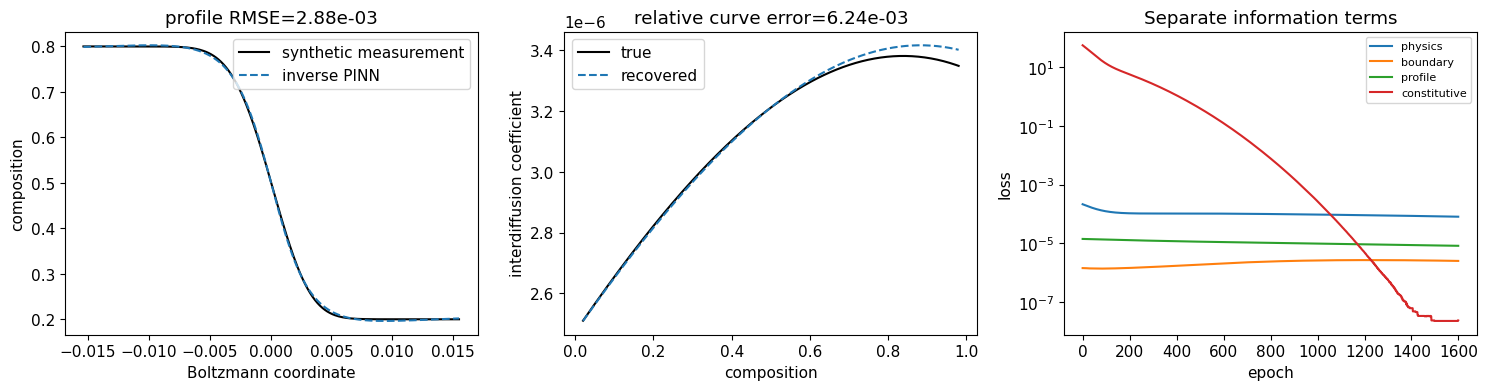

In [76]:
# Evaluate the recovered profile and diffusivity on points not used for fitting.
with torch.no_grad():
    cpred = inv_model(to_tensor(lam_hat[:,None])).cpu().numpy().ravel()
    cgrid_t = to_tensor(cq[:,None])
    Dpred = inv_model.Dtilde(cgrid_t).cpu().numpy().ravel()
Dtrue = Dtilde_np(cq, a_true)

fig, ax = plt.subplots(1,3,figsize=(15,4.2))
ax[0].plot(lam,c_latest,"k",label="synthetic measurement")
ax[0].plot(lam,cpred,"--",label="inverse PINN")
ax[0].set(xlabel="Boltzmann coordinate",ylabel="composition",
          title=f"profile RMSE={rmse(c_latest,cpred):.2e}"); ax[0].legend()
ax[1].plot(cq,Dtrue,"k",label="true")
ax[1].plot(cq,Dpred,"--",label="recovered")
ax[1].set(xlabel="composition",ylabel="interdiffusion coefficient",
          title=f"relative curve error={np.linalg.norm(Dpred-Dtrue)/np.linalg.norm(Dtrue):.2e}")
ax[1].legend()
for key in ["physics","boundary","profile","constitutive"]:
    ax[2].semilogy(history_inv[key],label=key)
ax[2].set(xlabel="epoch",ylabel="loss",title="Separate information terms")
ax[2].legend(fontsize=8); plt.tight_layout(); plt.show()

The correct conclusion is conditional: the recovered curve is selected by the observed profile, diffusion equation, end compositions, positivity, chosen Arrhenius–quadratic family, fixed thermodynamic information and two anchors. Scaling and loss weights affect optimization but are not additional physics.


# Part V — Fourier Neural Operator: Learn a Map Between Fields

## From one solution to a family of solutions

Earlier, a neural network was used to learn one particular solution of a differential equation. In operator learning, the aim is broader: we want one trained model that can solve an entire family of related problems.

Consider the boundary-value problem

$$
-u''(x)=f(x),
\qquad
0<x<1,
$$

with boundary conditions

$$
u(0)=0,
\qquad
u(1)=0.
$$

Here, $f(x)$ is the source term and $u(x)$ is the corresponding solution.

For one fixed source function $f(x)$, solving the equation gives one solution function $u(x)$. If the source function changes, the solution also changes.

For example,

$$
f_1(x)
\longrightarrow
u_1(x),
$$

$$
f_2(x)
\longrightarrow
u_2(x),
$$

and

$$
f_3(x)
\longrightarrow
u_3(x).
$$

The mathematical rule that maps each complete source function to its complete solution function is called a **solution operator**.

We write this as

$$
\mathcal{G}:f(\cdot)\mapsto u(\cdot).
$$

The notation $f(\cdot)$ emphasizes that the input is an entire function, not a single number. Similarly, $u(\cdot)$ is an entire output function.

For the Poisson equation, the operator $\mathcal{G}$ means:

$$
u=\mathcal{G}(f).
$$

Thus, the operator takes the full field $f(x)$ and returns the full field $u(x)$.

## Function learning and operator learning

In ordinary function learning, a neural network may learn a relation such as

$$
x\mapsto y.
$$

The input is usually a finite list of numbers, and the output is another number or a finite list of numbers.

In operator learning, the mapping is

$$
f(x)\mapsto u(x).
$$

Both the input and output are functions or fields.

After discretization on grid points $x_1,\ldots,x_N$, the input field is represented by

$$
\mathbf{f}
=
\begin{bmatrix}
f(x_1)\\
f(x_2)\\
\vdots\\
f(x_N)
\end{bmatrix},
$$

and the output field is represented by

$$
\mathbf{u}
=
\begin{bmatrix}
u(x_1)\\
u(x_2)\\
\vdots\\
u(x_N)
\end{bmatrix}.
$$

The neural operator therefore learns a mapping from one discretized field to another:

$$
\mathbf{f}\mapsto\mathbf{u}.
$$

However, the underlying goal is still to approximate the continuous operator

$$
\mathcal{G}:f(\cdot)\mapsto u(\cdot).
$$

## Why learn an operator?

A conventional numerical solver solves the differential equation separately for every new source function.

For each new $f(x)$, it must again assemble and solve the discretized equations.

An operator model is trained using many input-output pairs:

$$
\left\{
f^{(j)}(x),
u^{(j)}(x)
\right\}_{j=1}^{N_{\mathrm{train}}}.
$$

After training, the model can predict the solution for a new source function:

$$
f_{\mathrm{new}}(x)
\longrightarrow
u_{\mathrm{pred}}(x).
$$

The expensive work is moved to the training stage. Prediction for a new input field can then be much faster.

This is useful when the same class of differential equations must be solved many times, such as in

- parameter studies,
- uncertainty analysis,
- optimization,
- inverse problems,
- real-time prediction,
- and digital twins.

## Fourier representation of a field

A field can be described in physical space by its values at different positions. The same field can also be described as a combination of spatial waves.

For a periodic function, a Fourier representation has the form

$$
f(x)
=
\sum_{k}
\widehat{f}_k
e^{2\pi i kx}.
$$

Here,

- $k$ is the wave number,
- $e^{2\pi i kx}$ is a spatial wave,
- $\widehat{f}_k$ is the amplitude of that wave.

Each value of $k$ corresponds to one **Fourier mode**.

Low Fourier modes vary slowly in space and describe broad features of the field.

High Fourier modes vary rapidly in space and describe fine details.

For example:

- a low mode may represent the overall shape of a concentration profile,
- a high mode may represent sharp local variations or small-scale oscillations.

The Fourier transform converts the field from physical space to Fourier space:

$$
f(x)
\quad
\longrightarrow
\quad
\widehat{f}_k.
$$

The inverse Fourier transform reconstructs the field:

$$
\widehat{f}_k
\quad
\longrightarrow
\quad
f(x).
$$

## Main idea of the Fourier Neural Operator

The Fourier Neural Operator, abbreviated as **FNO**, learns how to transform one field into another by working partly in Fourier space.

A typical FNO layer performs the following steps:

1. Transform the current field from physical space to Fourier space.
2. Multiply selected Fourier modes by trainable weights.
3. Transform the result back to physical space.
4. Add a local linear transformation.
5. Apply a nonlinear activation function.

In symbolic form, one FNO layer may be written as

$$
v_{l+1}(x)
=
\sigma
\left[
Wv_l(x)
+
\mathcal{F}^{-1}
\left(
R_l(k)\,
\mathcal{F}[v_l](k)
\right)
\right].
$$

Here,

- $v_l(x)$ is the field entering layer $l$,
- $\mathcal{F}$ is the Fourier transform,
- $\mathcal{F}^{-1}$ is the inverse Fourier transform,
- $R_l(k)$ contains trainable weights for the retained Fourier modes,
- $W$ is a learned local linear transformation,
- $\sigma$ is a nonlinear activation function.

The Fourier part allows information at one position to influence distant positions. This is important because solutions of differential equations often depend on the input field over the whole domain.

## Why only some Fourier modes are retained

In many physical fields, most of the large-scale behavior is contained in the lower Fourier modes.

FNO commonly keeps only a chosen number of low modes and discards the higher modes.

If the number of retained modes is $m$, then the model uses

$$
k=0,1,\ldots,m-1.
$$

Keeping fewer modes reduces the number of trainable parameters and the computational cost.

However, too few modes may remove important fine-scale information. Too many modes increase cost and may make the model more sensitive to noise.

The number of retained modes is therefore a model choice.

## Input and output of the FNO in this example

For each training problem, the input is the discretized source field

$$
f(x_i),
\qquad
i=1,\ldots,N.
$$

The output is the corresponding discretized solution field

$$
u(x_i),
\qquad
i=1,\ldots,N.
$$

The FNO is trained using many pairs of the form

$$
f^{(j)}(x_i)
\longrightarrow
u^{(j)}(x_i).
$$

After training, it receives a new source field sampled on the grid and predicts the entire solution field in one forward pass.

## FNO is not automatically physics-informed

A standard FNO is usually trained using paired input-output data.

Its loss may be

$$
L_{\mathrm{data}}
=
\frac{1}{N_{\mathrm{train}}}
\sum_{j=1}^{N_{\mathrm{train}}}
\left\|
u_{\mathrm{pred}}^{(j)}
-
u_{\mathrm{true}}^{(j)}
\right\|_2^2.
$$

This loss compares the predicted solution with a known reference solution.

The governing equation does not necessarily appear in the loss. Therefore, a standard FNO is an operator-learning model, but it is not automatically physics-informed.

An FNO becomes physics-informed only when physical information is included explicitly. For example, one may add

- the differential-equation residual,
- boundary-condition errors,
- conservation laws,
- symmetry constraints,
- or known constitutive relations.

A physics-informed operator loss may have the form

$$
L
=
L_{\mathrm{data}}
+
\lambda_{\mathrm{eq}}L_{\mathrm{eq}}
+
\lambda_{\mathrm{bc}}L_{\mathrm{bc}}.
$$

Thus,

$$
\text{FNO}
\neq
\text{physics-informed by default}.
$$

The architecture and the training loss are separate choices.

## FNO and PINO

A **Physics-Informed Neural Operator**, abbreviated as **PINO**, combines operator learning with physical constraints.

An FNO may be used as the operator architecture, while the governing equation is added to the training loss.

Therefore, one possible relationship is

$$
\text{PINO}
=
\text{neural operator architecture}
+
\text{physics-based loss}.
$$

In this notebook:

- the FNO section learns the map $f(\cdot)\mapsto u(\cdot)$ mainly from paired data;
- the PINO section adds the Poisson-equation residual and boundary conditions to the operator training.

The key distinction is:

$$
\text{PINN learns one or a few solutions},
$$

whereas

$$
\text{FNO or PINO learns a family of solution maps}.
$$


## Generate exact field-to-field pairs

Random forcing fields are sums of sine waves. Their exact solutions follow by dividing each sine coefficient by $(k\pi)^2$. One dataset row is one whole problem, not one coordinate.

In [77]:
# Generate many forcing fields and their exact Poisson solutions.
nx_op, n_total, kmax = 64, 256, 6
x_op = np.linspace(0,1,nx_op)
rr = np.random.default_rng(SEED)
coeff = rr.normal(0,1,(n_total,kmax))
kvals = np.arange(1,kmax+1)
S = np.sin(np.pi*np.outer(x_op,kvals))
f_fields = coeff @ S.T
u_fields = (coeff/(np.pi*kvals)**2) @ S.T
order = rr.permutation(n_total)
op_train, op_val, op_test = order[:160], order[160:208], order[208:]
f_mean, f_std = f_fields[op_train].mean(), f_fields[op_train].std()
u_mean, u_std = u_fields[op_train].mean(), u_fields[op_train].std()
fn = (f_fields-f_mean)/f_std
un = (u_fields-u_mean)/u_std
print("field arrays:", f_fields.shape, u_fields.shape)

field arrays: (256, 64) (256, 64)


Normalization uses training fields only. Validation and test sets contain entirely unseen forcing functions. Splitting grid points from the same field across sets would leak one physical problem into several subsets.

## Implement one-dimensional FNO

Each spectral layer transforms internal channels, multiplies selected Fourier modes by learned complex weights, transforms back, adds a local linear path and applies an activation. The coordinate is supplied alongside the forcing field.

In [78]:
# Define the spectral layer and the one-dimensional Fourier neural operator.
class SpectralConv1d(nn.Module):
    def __init__(self, width, modes):
        super().__init__()
        self.modes = modes
        scale = 1/(width*width)
        self.weight = nn.Parameter(scale*torch.randn(
            width,width,modes,dtype=torch.cfloat))
    def forward(self, v):
        vh = torch.fft.rfft(v)
        out = torch.zeros(v.size(0),v.size(1),vh.size(-1),
                          dtype=torch.cfloat,device=v.device)
        m = min(self.modes,vh.size(-1))
        out[:,:,:m] = torch.einsum("bim,iom->bom",
                                   vh[:,:,:m],self.weight[:,:,:m])
        return torch.fft.irfft(out,n=v.size(-1))

class FNO1d(nn.Module):
    def __init__(self, width=24, modes=10, layers=3):
        super().__init__()
        self.lift = nn.Linear(2,width)
        self.spec = nn.ModuleList([SpectralConv1d(width,modes) for _ in range(layers)])
        self.local = nn.ModuleList([nn.Conv1d(width,width,1) for _ in range(layers)])
        self.proj = nn.Sequential(nn.Linear(width,32),nn.GELU(),nn.Linear(32,1))
    def forward(self, f, grid):
        v = self.lift(torch.stack([f,grid.expand_as(f)],dim=-1)).permute(0,2,1)
        for s,w in zip(self.spec,self.local):
            v = torch.nn.functional.gelu(s(v)+w(v))
        raw = self.proj(v.permute(0,2,1)).squeeze(-1)
        return 4*grid.expand_as(raw)*(1-grid.expand_as(raw))*raw

The final factor enforces zero endpoint values for every output. Both FNO and PINO will use this same hard boundary construction, so their later comparison isolates the addition of the governing-equation residual.

## Train FNO using solved examples only

Only 48 labelled training field pairs are used to make the low-data comparison with PINO visible. Validation fields select the retained epoch. The differential equation is not present in this loss.

In [79]:
# Train the FNO using paired input and solution fields.
grid_t = to_tensor(x_op[None,:])
f_all_t, u_all_t = to_tensor(fn), to_tensor(un)
labelled = op_train[:48]
torch.manual_seed(SEED)
fno = FNO1d().to(device)
opt_fno = torch.optim.Adam(fno.parameters(),lr=3e-3)
fno_hist, best_fno = {"train":[],"val":[]}, (np.inf,None)
for epoch in range(260):
    opt_fno.zero_grad()
    pred = fno(f_all_t[labelled],grid_t)
    loss = torch.mean((pred-u_all_t[labelled])**2)
    loss.backward(); opt_fno.step()
    with torch.no_grad():
        val = torch.mean((fno(f_all_t[op_val],grid_t)-u_all_t[op_val])**2)
    fno_hist["train"].append(float(loss.detach().cpu()))
    fno_hist["val"].append(float(val.cpu()))
    if fno_hist["val"][-1] < best_fno[0]:
        best_fno=(fno_hist["val"][-1],copy.deepcopy(fno.state_dict()))
fno.load_state_dict(best_fno[1])

<All keys matched successfully>

The FNO has learned from paired examples $f\mapsto u$. Fourier operations provide a useful global architecture, but they do not tell the model the Poisson equation.

# Part VI — PINO: train the operator with physics

## Physics loss for a grid-valued output

For an operator output stored on a grid, a centred finite difference estimates

$$
u''(x_i)\approx\frac{u_{i+1}-2u_i+u_{i-1}}{\Delta x^2}.
$$

The PINO residual is $r=-u''-f$. In this notebook, PINO means the same FNO backbone plus data and equation losses. Other PINO implementations may use different operator architectures or derivative calculations.

## 30. Define operator diagnostics

The next cell converts normalized outputs back to physical scale, calculates the finite-difference residual, relative field error and boundary error. These functions are used for both models.

In [80]:
# Define numerical checks for solution error and equation residual.
dx_op = x_op[1]-x_op[0]
f_scale = float(np.sqrt(np.mean(f_fields[op_train]**2)))

def physical_u(pred_norm):
    return pred_norm*u_std + u_mean
def operator_physics_loss(model, indices):
    pred_n = model(f_all_t[indices],grid_t)
    up = physical_u(pred_n)
    fp = f_all_t[indices]*f_std + f_mean
    uxx = (up[:,2:]-2*up[:,1:-1]+up[:,:-2])/dx_op**2
    return torch.mean(((-uxx-fp[:,1:-1])/f_scale)**2)
def operator_metrics(model, indices):
    with torch.no_grad():
        pn = model(f_all_t[indices],grid_t)
        up = physical_u(pn).cpu().numpy()
    ut = u_fields[indices]
    rel = np.mean(np.linalg.norm(up-ut,axis=1)/np.linalg.norm(ut,axis=1))
    d2 = (up[:,2:]-2*up[:,1:-1]+up[:,:-2])/dx_op**2
    residual_rms = np.sqrt(np.mean((-d2-f_fields[indices,1:-1])**2))
    return rel, residual_rms, up

Finite differences introduce their own discretization error. Consequently, even the exact continuous solution has a small nonzero discrete residual. A residual must always be interpreted relative to its derivative approximation and grid.

## Continue with physics-informed operator training

The PINO starts from the data-trained FNO and uses all 160 training forcing fields in the equation loss, although only 48 have labels in the data loss. The unlabelled fields are not information-free: their forcing functions, equation and boundary construction are known.

In [29]:
# Continue training with both labelled data and the Poisson equation.
pino = copy.deepcopy(fno)
opt_pino = torch.optim.Adam(pino.parameters(),lr=1e-3)
pino_hist = {"data":[],"physics":[],"val":[]}
best_pino = (np.inf,None)
for epoch in range(220):
    opt_pino.zero_grad()
    pred_lab = pino(f_all_t[labelled],grid_t)
    Ldata = torch.mean((pred_lab-u_all_t[labelled])**2)
    Lphys = operator_physics_loss(pino,op_train)
    total = Ldata + 0.03*Lphys
    total.backward(); opt_pino.step()
    with torch.no_grad():
        Lval = torch.mean((pino(f_all_t[op_val],grid_t)-u_all_t[op_val])**2)
    pino_hist["data"].append(float(Ldata.detach().cpu()))
    pino_hist["physics"].append(float(Lphys.detach().cpu()))
    pino_hist["val"].append(float(Lval.cpu()))
    score = pino_hist["val"][-1] + 0.03*float(
        operator_physics_loss(pino,op_val).detach().cpu())
    if score < best_pino[0]:
        best_pino=(score,copy.deepcopy(pino.state_dict()))
pino.load_state_dict(best_pino[1])

<All keys matched successfully>

PINO has not been given hidden solution labels for the additional fields. Physics supplies a usable residual for them. The weight 0.03 balances normalized numerical losses and is not a physical constant.

## Compare FNO and PINO on untouched problems

The next cell reports solution error and equation residual on test forcing fields that influenced neither parameter updates nor model selection. It also plots one complete unseen problem.

FNO  mean relative solution error=8.219e-02, residual RMS=6.416e+00
PINO mean relative solution error=6.298e-02, residual RMS=1.017e+00


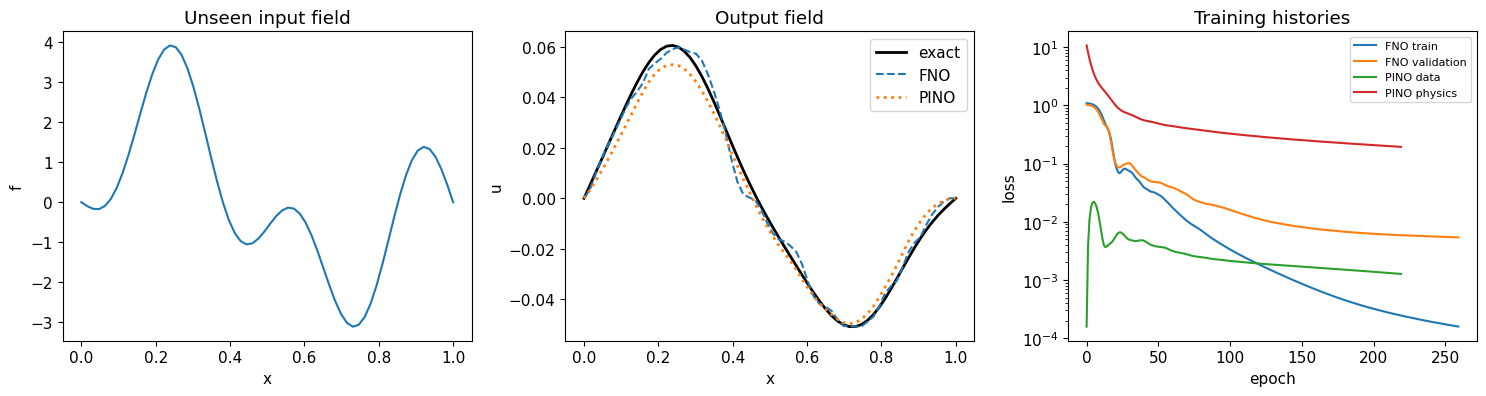

In [81]:
# Compare FNO and PINO on complete test problems not used in training.
fno_rel,fno_res,fno_up = operator_metrics(fno,op_test)
pino_rel,pino_res,pino_up = operator_metrics(pino,op_test)
print(f"FNO  mean relative solution error={fno_rel:.3e}, residual RMS={fno_res:.3e}")
print(f"PINO mean relative solution error={pino_rel:.3e}, residual RMS={pino_res:.3e}")

j=0
idx=op_test[j]
fig,ax=plt.subplots(1,3,figsize=(15,4.1))
ax[0].plot(x_op,f_fields[idx]); ax[0].set(title="Unseen input field",xlabel="x",ylabel="f")
ax[1].plot(x_op,u_fields[idx],"k",lw=2,label="exact")
ax[1].plot(x_op,fno_up[j],"--",label="FNO")
ax[1].plot(x_op,pino_up[j],":",lw=2,label="PINO")
ax[1].set(title="Output field",xlabel="x",ylabel="u"); ax[1].legend()
ax[2].semilogy(fno_hist["train"],label="FNO train")
ax[2].semilogy(fno_hist["val"],label="FNO validation")
ax[2].semilogy(pino_hist["data"],label="PINO data")
ax[2].semilogy(pino_hist["physics"],label="PINO physics")
ax[2].set(title="Training histories",xlabel="epoch",ylabel="loss"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

Physics information often reduces residual and can improve data efficiency, but PINO is not guaranteed to outperform FNO. Wrong equations, incomplete conditions, inaccurate derivatives, poor loss balance, failed optimization or out-of-family inputs can all degrade it.

## 33. FNO, PINN and PINO are different objects

| Method | Input | Output | Problems represented | Main training information |
|---|---|---|---|---|
| PINN | coordinate $x$ | value $u(x)$ | usually one | equation, conditions, optional data |
| FNO | field $f(\cdot)$ | field $u(\cdot)$ | a trained family | paired fields |
| PINO | field $f(\cdot)$ | field $u(\cdot)$ | a trained family | paired fields and/or equation residuals |

An FNO prediction outside the training distribution is extrapolation. Running at a different grid resolution may be possible architecturally, but accuracy is not guaranteed and must be tested.

# Part VII — Can PINO be used for an inverse problem?

## Freeze the forward PINO and estimate its input parameters

Yes. A safe pattern is:

1. train a forward PINO over a family;
2. freeze its weights;
3. describe an unknown input field with a few parameters;
4. change those parameters until the PINO output matches an observation;
5. verify the result using the original high-accuracy solver.

The next example recovers two coefficients in

$$
f_\alpha(x)=\alpha_1\sin(\pi x)+\alpha_2\sin(2\pi x)
$$

from observations of its solution. This is an operator-assisted inverse problem.

In [89]:
# Use the trained PINO as a fixed forward model.
#
# The PINO parameters were already learned during operator training.
# They are frozen here because this inverse problem should update only
# the unknown source coefficients, not the neural-operator weights.
for parameter in pino.parameters():
    parameter.requires_grad_(False)


# Define the true coefficients used to generate the synthetic observation.
#
# The unknown source field has the form
#
# f(x) = alpha_1 sin(pi x) + alpha_2 sin(2 pi x).
#
# These values are hidden from the inverse optimizer and are used only
# to generate and later check the synthetic result.
alpha_true = np.array(
    [0.8, -0.55],
    dtype=np.float32
)


# Construct the unknown source field on the operator grid.
f_unknown = (
    alpha_true[0] * np.sin(np.pi * x_op)
    + alpha_true[1] * np.sin(2.0 * np.pi * x_op)
)


# Construct the exact solution of
#
# -u''(x) = f(x),
# u(0) = u(1) = 0.
#
# Since
#
# -d^2/dx^2 [sin(n pi x)/(n pi)^2] = sin(n pi x),
#
# each sine component of the source has a known solution.
u_observed = (
    alpha_true[0]
    * np.sin(np.pi * x_op)
    / np.pi**2
    +
    alpha_true[1]
    * np.sin(2.0 * np.pi * x_op)
    / (2.0 * np.pi)**2
)


# Select a subset of interior grid points as sensors.
#
# The first and last three grid points are excluded so that the inverse
# calculation relies on interior solution measurements rather than
# directly using the boundary region.
#
# Every third remaining grid point is used as a sensor.
sensors = np.arange(
    3,
    nx_op - 3,
    3
)


# Define the two tunable inverse parameters.
#
# alpha[0] multiplies sin(pi x).
# alpha[1] multiplies sin(2 pi x).
#
# nn.Parameter tells PyTorch that these values should be updated
# by gradient-based optimization.
#
# The initial guess [0.1, 0.1] is intentionally different from
# the true values [0.8, -0.55].
alpha = nn.Parameter(
    torch.tensor(
        [0.1, 0.1],
        dtype=torch.float32,
        device=device
    )
)


# Create an optimizer that updates only alpha.
#
# The PINO parameters are not included in this optimizer.
opt_alpha = torch.optim.Adam(
    [alpha],
    lr=0.035
)


# Precompute the two basis functions on the operator grid.
#
# These tensors remain fixed during the inverse calculation.
sin1 = to_tensor(
    np.sin(np.pi * x_op)
)

sin2 = to_tensor(
    np.sin(2.0 * np.pi * x_op)
)


# Convert the observed solution to a PyTorch tensor.
u_observed_tensor = to_tensor(
    u_observed
)


# Store the inverse-problem loss after each epoch.
inverse_history = []


# Adjust alpha so that the PINO-predicted solution matches
# the observed solution at the sensor locations.
for epoch in range(500):

    # Remove gradients from the previous optimization step.
    opt_alpha.zero_grad()


    # Construct the current trial source field using the
    # present values of the two tunable coefficients.
    f_trial = (
        alpha[0] * sin1
        + alpha[1] * sin2
    )


    # Normalize the trial source using the same mean and standard
    # deviation used during PINO training.
    #
    # The PINO expects normalized input fields.
    f_trial_normalized = (
        f_trial - f_mean
    ) / f_std


    # Use the frozen PINO to predict the normalized solution field.
    #
    # [None, :] adds a batch dimension because the PINO expects
    # input with shape:
    #
    # batch size x number of grid points
    u_pred_normalized = pino(
        f_trial_normalized[None, :],
        grid_t
    )[0]


    # Convert the PINO output back to physical solution units.
    u_predicted = physical_u(
        u_pred_normalized
    )


    # Compare the predicted and observed solutions only at
    # the selected sensor locations.
    inverse_loss = torch.mean(
        (
            u_predicted[sensors]
            - u_observed_tensor[sensors]
        )**2
    )


    # Calculate the gradient of the sensor mismatch with respect
    # to alpha[0] and alpha[1].
    inverse_loss.backward()


    # Update the two source coefficients.
    opt_alpha.step()


    # Store the loss as an ordinary Python number.
    inverse_history.append(
        inverse_loss.item()
    )


# Display the known coefficients and the recovered coefficients.
print(
    "True input coefficients:    ",
    alpha_true
)

print(
    "PINO-inferred coefficients: ",
    alpha.detach().cpu().numpy()
)

True input coefficients:     [ 0.8  -0.55]
PINO-inferred coefficients:  [ 0.79165363 -0.5352339 ]


The recovered values may contain small surrogate bias because the PINO is approximate. A close output fit does not prove that a more general inverse is unique. Multiple profiles, independent anchors, uncertainty estimates and an original-solver verification are required for difficult constitutive inversion.

## The key idea is that the trained PINO is now kept fixed and used as a differentiable forward solver. Only the two unknown source coefficients are adjusted.



### What are the tunable parameters?

The source field is assumed to have the form

$$
f(x) = \alpha_1\sin(\pi x)
+
\alpha_2\sin(2\pi x).
$$

The two tunable parameters are therefore

$$
\alpha_1
\quad\text{and}\quad
\alpha_2.
$$

In the code, they are stored in

```python
alpha = nn.Parameter(
    torch.tensor([0.1, 0.1], device=device)
)
```

Thus,

```python
alpha[0]
```

represents $\alpha_1$, and

```python
alpha[1]
```

represents $\alpha_2$.

They control the amplitudes of the two spatial modes:

$$
\sin(\pi x)
$$

and

$$
\sin(2\pi x).
$$

The PINO weights are **not tunable in this inverse stage**. They are frozen by

```python
for parameter in pino.parameters():
    parameter.requires_grad_(False)
```

Therefore, the optimization problem is only

$$
\min_{\alpha_1,\alpha_2}
\frac{1}{N_s}
\sum_{j=1}^{N_s}
\left[
u_{\mathrm{PINO}}(x_j;\alpha_1,\alpha_2)-
u_{\mathrm{observed}}(x_j)
\right]^2.
$$

Here, $N_s$ is the number of sensors.

The computational chain is

$$
(\alpha_1,\alpha_2)
\rightarrow
f_{\mathrm{trial}}(x)
\rightarrow
u_{\mathrm{PINO}}(x)
\rightarrow
L_{\mathrm{inverse}}.
$$

Because every step is differentiable, PyTorch can calculate

$$
\frac{\partial L_{\mathrm{inverse}}}{\partial\alpha_1}
\qquad\text{and}\qquad
\frac{\partial L_{\mathrm{inverse}}}{\partial\alpha_2}.
$$

Adam then updates the coefficients until the predicted solution agrees with the sensor observations.

## Map the operator-assisted inverse idea to binary diffusion

A reusable diffusion PINO could represent

$$
\mathcal G_\theta:[c_0(x),\widetilde D_\alpha(c),T,t]\mapsto c(x,t).
$$

After forward training, freeze $\theta$, vary $\alpha$, and minimize profile mismatch plus constitutive anchors and priors. This is attractive when many couples or temperatures must be inverted. For only one experiment, the direct inverse PINN is usually simpler.

PINO accelerates repeated inversion; it does not remove non-uniqueness. A recovered law must remain inside the operator's training family and must be verified with the original solver and independent experiments.

## Before accepting any learned result, ask:

1. What mathematical object is represented: coefficients, one function, one field, or an operator?
2. Which quantities are trainable?
3. Which observations update parameters?
4. Which equations, boundaries, constitutive assumptions and anchors enter the loss?
5. Which information is reserved for validation and final testing?
6. Is the result interpolation or extrapolation?
7. Could different parameters produce nearly the same observable?
8. Has the result been checked using an independent solver or experiment?

**Network approximator ≠ Hall–Petch equation.  
PINN trial field ≠ governing equation.  
FNO architecture ≠ physics-informed training.  
PINO operator ≠ guaranteed identifiability.**

In [32]:
# Run basic checks for missing values, wrong shapes, and failed calculations.
assert np.isfinite(sigma0_ols) and np.isfinite(k_ols)
assert u_pred_p.shape == u_exact_p.shape and np.all(np.isfinite(u_pred_p))
assert cpred.shape == c_latest.shape and np.all(np.isfinite(Dpred))
assert fno_up.shape == pino_up.shape == (len(op_test),nx_op)
assert np.all(np.isfinite(alpha.detach().cpu().numpy()))
print("All implementation checks passed.")
print("Forward PINN relative error:",
      np.linalg.norm(u_pred_p-u_exact_p)/np.linalg.norm(u_exact_p))
print("Binary inverse profile RMSE:",rmse(c_latest,cpred))
print("FNO/PINO test relative errors:",fno_rel,pino_rel)

All implementation checks passed.
Forward PINN relative error: 0.0003520315970574072
Binary inverse profile RMSE: 0.002883477198335181
FNO/PINO test relative errors: 0.08219062050629994 0.06298140770068296


If this cell prints “All implementation checks passed,” the notebook has run in the intended order without NaNs, shape errors or broken links between calculations. Scientific acceptance still depends on uncertainty, identifiability, model discrepancy and independent validation.